In [1]:
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [3]:
sb.competitions()[sb.competitions().country_name=='England']

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
25,37,90,England,FA Women's Super League,female,False,False,2020/2021,2025-04-23T14:16:46.924831,2021-06-13T16:17:31.694,None,2025-04-23T14:16:46.924831
26,37,42,England,FA Women's Super League,female,False,False,2019/2020,2024-02-12T15:05:34.211400,2021-06-13T16:17:31.694,None,2024-02-12T15:05:34.211400
27,37,4,England,FA Women's Super League,female,False,False,2018/2019,2024-08-07T17:22:40.334287,2021-06-13T16:17:31.694,None,2024-08-07T17:22:40.334287
64,2,27,England,Premier League,male,False,False,2015/2016,2025-04-23T14:36:29.347042,2021-06-13T16:17:31.694,None,2025-04-23T14:36:29.347042
65,2,44,England,Premier League,male,False,False,2003/2004,2025-06-24T13:53:07.585114,2021-06-13T16:17:31.694,None,2025-06-24T13:53:07.585114


In [8]:
match_ids = sb.matches(competition_id = 2, season_id = 27)['match_id'].tolist()

In [9]:
match_ids[0:5]

[3754058, 3754245, 3754136, 3754037, 3754039]

In [11]:
df = pd.concat([sb.events(match_id = match) for match in match_ids])

In [13]:
#from tqdm import tqdm
#pd.concat([sb.events(match_id=match) for match in tqdm(match_ids)])

In [14]:
df.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9153e9f4-f69c-4e04-8f64-505592e212cd,1,NaN,NaN,3754058,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Leicester City,22,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Leicester City,22,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,NaN,NaN,3754058,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Leicester City,22,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4141, 'lineup': [{'player': {'id...",AFC Bournemouth,28,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,NaN,NaN,3754058,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Leicester City,22,[100362ee-9311-4187-bd8a-0201d9db2565],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100362ee-9311-4187-bd8a-0201d9db2565,4,NaN,NaN,3754058,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [15]:
df['timestamp']=pd.to_timedelta(df['timestamp'])
df['timestamp_offset'] = pd.Timedelta(0, 'minutes')
df['timestamp_offset'] = df['timestamp_offset'].mask(df['period'] ==2, pd.Timedelta(45, 'minutes'))
df['game_timestamp'] = df['timestamp_offset'] + df['timestamp']

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2331803121.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['timestamp_offset'] = pd.Timedelta(0, 'minutes')
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2331803121.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['game_timestamp'] = df['timestamp_offset'] + df['timestamp']


In [16]:
df = df.sort_values(['match_id','period','game_timestamp','index']).drop(columns = {'timestamp_offset'})

In [17]:
df.reset_index(inplace=True)
#df.drop(columns = {'level_0'},inplace=True)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2087621201.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.reset_index(inplace=True)


In [18]:
df.drop(columns = {'level_0'},inplace=True)

In [19]:
df.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6bbafb9c-9e4f-45bf-80f2-6f93c8b4d5e2,1,NaN,NaN,3753972,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Swansea City,26,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Swansea City,26,0 days 00:00:00,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,07aa1c9f-aff7-42aa-b763-39a478b8e5ea,2,NaN,NaN,3753972,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Swansea City,26,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4411, 'lineup': [{'player': {'id...",AFC Bournemouth,28,0 days 00:00:00,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a893074f-957f-4272-8d64-92020f98337f,3,NaN,NaN,3753972,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Swansea City,26,[0ee3b84e-9975-48e0-819a-daeee9dc8880],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:00:00,Half Start,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0ee3b84e-9975-48e0-819a-daeee9dc8880,4,NaN,NaN,3753972,0,NaN,NaN,NaN,NaN,

In [20]:
Passes = df[df['type'] == 'Pass']
Shots = df[df['type'] == 'Shot']

In [34]:
Passes[['match_id','minute','location','pass_end_location','player_id','player','pass_recipient','pass_recipient_id','position','team','type','game_timestamp']].head()

,match_id,minute,location,pass_end_location,player_id,player,pass_recipient,pass_recipient_id,position,team,type,game_timestamp
5,3753972,0,"[61.0, 40.1]","[60.2, 40.7]",15996.0,Éderzito António Macedo Lopes,Jonjo Shelvey,3057.0,Center Forward,Swansea City,Pass,0 days 00:00:00.548000
7,3753972,0,"[60.5, 42.1]","[52.4, 41.6]",3057.0,Jonjo Shelvey,Leon Britton,4631.0,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000
11,3753972,0,"[53.1, 42.3]","[33.2, 60.9]",4631.0,Leon Britton,Kyle Bartley,4726.0,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000
14,3753972,0,"[33.4, 59.7]","[28.5, 31.1]",4726.0,Kyle Bartley,Ashley Williams,3644.0,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000
17,3753972,0,"[28.5, 33.9]","[26.8, 60.2]",3644.0,Ashley Williams,Kyle Bartley,4726.0,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000


In [35]:
Shots[['match_id','minute','location','shot_outcome','player_id','player','pass_recipient','pass_recipient_id','position','team','type','timestamp']].head()

,match_id,minute,location,shot_outcome,player_id,player,pass_recipient,pass_recipient_id,position,team,type,timestamp
143,3753972,3,"[101.8, 49.1]",Off T,3343.0,Dan Gosling,NaN,NaN,Left Defensive Midfield,AFC Bournemouth,Shot,0 days 00:03:11.382000
366,3753972,8,"[80.9, 43.8]",Blocked,3343.0,Dan Gosling,NaN,NaN,Left Defensive Midfield,AFC Bournemouth,Shot,0 days 00:08:38.577000
415,3753972,9,"[111.9, 39.9]",Goal,3346.0,Joshua King,NaN,NaN,Center Forward,AFC Bournemouth,Shot,0 days 00:09:47.445000
435,3753972,11,"[106.6, 28.7]",Saved,3449.0,Wayne Routledge,NaN,NaN,Right Wing,Swansea City,Shot,0 days 00:11:05.741000
440,3753972,11,"[112.4, 48.6]",Wayward,4726.0,Kyle Bartley,NaN,NaN,Right Center Back,Swansea City,Shot,0 days 00:11:37.263000


In [40]:
#for every shot in the data frame 
#find the pass that occured 15 seconds before shot took place


In [41]:
passes_within_15s_shot = []
for i in tqdm(range(len(Shots))):
    shot_time = Shots.iloc[i]['game_timestamp']
    shot_period = Shots.iloc[i]['period']
    shot_team = Shots.iloc[i]['team']
    shot_match = Shots.iloc[i]['match_id']
    shot_index = Shots.index[i]
    shot_id = Shots.iloc[i].get('id')
    prior_passes = Passes[(Passes['game_timestamp']<shot_time)&
                          (shot_time - Passes['game_timestamp']<= pd.Timedelta(seconds=15))&
                          (Passes['period'] == shot_period)&
                          (Passes['team'] == shot_team)&
                          (Passes['match_id'] == shot_match)&
                          (Passes['pass_outcome'].isna())].copy()  # Add this line
    prior_passes['linked_shot_time'] = shot_time
    prior_passes['linked_shot_index'] = shot_index
    prior_passes['linked_shot_id'] = shot_id
    passes_within_15s_shot.append(prior_passes)
passes_within_15s_shot_df = pd.concat(passes_within_15s_shot)

100%|███████████████████████████████████████| 9908/9908 [08:42<00:00, 18.95it/s]


In [42]:
passes_within_15s_shot_df.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp,linked_shot_time,linked_shot_index,linked_shot_id
126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.834888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2be51e25-52b7-4761-9582-198b2cad5b2b,126,NaN,"[56.0, 67.4]",3753972,3,NaN,NaN,NaN,NaN,-1.715838,NaN,Right Foot,NaN,NaN,NaN,"[54.7, 58.5]",Low Pass,NaN,8.994443,NaN,NaN,Andrew Surman,3344.0,NaN,NaN,NaN,NaN,Recovery,1,Regular Play,Matt Ritchie,3049.0,Right Midfield,8,AFC Bournemouth,28,"[1e0769b7-2491-4f0b-be25-183d7f2ecc3a, 2b2352f...",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:03:00.561000,Pass,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:03:00.561000,0 days 00:03:11.382000,143,c0218ff0-32e8-46de-8ed4-a22e7ee4fd48
128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.675914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ddd7b7a2-dae5-4477-8ec6-7f29487f1de5,128,NaN,"[54.7, 58.5]",3753972,3,NaN,NaN,NaN,NaN,0.501906,NaN,Left Foot,NaN,NaN,NaN,"[62.9, 63.0]",Low Pass,NaN,9.353609,NaN,NaN,Dan Gosling,3343.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Andrew Surman,3344.0,Right Defensive Midfield,8,AFC Bournemouth,28,[b64596d1-5c8a-424a-b30b-5aca5425e7dd],1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:03:01.396000,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:03:01.396000,0 days 00:03:11.382000,143,c0218ff0-32e8-46de-8ed4-a22e7ee4fd48
132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.992215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84a172ad-62f4-4ef2-bc32-862501cdc23b,132,NaN,"[62.9, 63.0]",3753972,3,NaN,NaN,NaN,NaN,-0.536146,NaN,Right Foot,NaN,NaN,NaN,"[76.7, 54.8]",Ground Pass,NaN,16.052414,NaN,NaN,Joshua King,3346.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Dan Gosling,3343.0,Left Defensive Midfield,8,AFC Bournemou

In [863]:
passes_within_15s_shot_df.to_csv('passes_within_15s_shot_df.csv')
passes_within_15s_shot_df.to_parquet('passes_within_15s_shot_df.parquet')


In [865]:
#pd.read_parquet('passes_within_15s_shot_df.parquet')

In [35]:
#P(Goal|Pass compelted) = P(Shot|Pass completed)*P(Goal|Shot)

In [ ]:
passes_within_15s_shot_df[['match_id','minute','location','pass_end_location','player_id','player','pass_recipient','pass_recipient_id','position','team','type','game_timestamp']].head()

In [ ]:
Passes[['match_id','minute','location','pass_end_location','player_id','player','pass_recipient','pass_recipient_id','position','team','type','game_timestamp','pass_outcome']].loc[126:140:1]

In [45]:
passes_within_15s_shot_df.index
passes_within_15s_shot_df.index.unique()

#basically there is a double counting because if there was a shot followed by another shot or soon after it will have different linked shot id's

Index([    126,     128,     132,     136,     140,     352,     362,     404,
           413,     422,
       ...
       1313235, 1313238, 1313254, 1313262, 1313265, 1313404, 1313451, 1313460,
       1313543, 1313545],
      dtype='int64', length=23850)

In [ ]:
Passes.index

In [46]:
pd.Series(Passes.index.isin(passes_within_15s_shot_df.index)).value_counts()

False    258529
True      23850
Name: count, dtype: int64

In [47]:
Passes.shape

(282379, 119)

In [48]:
Passes['within_15s_shot'] = 0
Passes['within_15s_shot']=Passes['within_15s_shot'].mask(Passes.index.isin(passes_within_15s_shot_df.index.unique()), 1)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/850544135.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Passes['within_15s_shot'] = 0
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/850544135.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Passes['within_15s_shot'] = 0
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/850544135.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

In [ ]:
Passes[['match_id','minute','location','pass_end_location','player_id','player','pass_recipient','pass_recipient_id','position','team','type','game_timestamp','pass_outcome','within_15s_shot']]

In [49]:
Passes[['x','y']] = Passes['location'].apply(pd.Series)
Passes[['end_x','end_y']] = Passes['pass_end_location'].apply(pd.Series)
Passes.drop(columns = {'location','pass_end_location'}, inplace=True)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2267003147.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Passes[['x','y']] = Passes['location'].apply(pd.Series)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2267003147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Passes[['x','y']] = Passes['location'].apply(pd.Series)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2267003147.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

In [ ]:
Passes[['match_id','minute','x','y','end_x','end_y','player_id','player','pass_recipient','pass_recipient_id','position','team','type','game_timestamp','pass_outcome','within_15s_shot']]

In [50]:
Passes.columns.tolist()

['ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_offensive',
 'foul_committed_penalty',
 'foul_committed_type',
 'foul_won_advantage',
 'foul_won_defensive',
 'foul_won_penalty',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_punched_out',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'interception_outcome',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_ou

In [51]:
pass_cols = Passes.filter(regex='^pass_').columns.tolist()
pass_cols


['pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_outcome',
 'pass_outswinging',
 'pass_recipient',
 'pass_recipient_id',
 'pass_shot_assist',
 'pass_switch',
 'pass_technique',
 'pass_through_ball',
 'pass_type',
 'pass_goal_assist',
 'pass_straight',
 'pass_no_touch',
 'pass_miscommunication']

In [52]:
specific_cols = ['match_id','play_pattern','minute','x','y','end_x','end_y','player_id','player','position','team','type','game_timestamp','within_15s_shot']

In [53]:
all_cols = pass_cols + specific_cols

In [54]:
Passes_copy = Passes[all_cols].drop(columns={'pass_assisted_shot_id','pass_goal_assist'})

In [55]:
Passes_copy.head()

,pass_aerial_won,pass_angle,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,pass_straight,pass_no_touch,pass_miscommunication,match_id,play_pattern,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot
5,NaN,2.498092,Right Foot,NaN,NaN,NaN,Ground Pass,NaN,1.000000,NaN,NaN,Jonjo Shelvey,3057.0,NaN,NaN,NaN,NaN,Kick Off,NaN,NaN,NaN,3753972,From Kick Off,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0
7,NaN,-3.079943,Left Foot,NaN,NaN,NaN,Ground Pass,NaN,8.115417,NaN,NaN,Leon Britton,4631.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3753972,From Kick Off,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0
11,NaN,2.389948,Right Foot,NaN,NaN,NaN,Ground Pass,NaN,27.239126,NaN,NaN,Kyle Bartley,4726.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3753972,From Kick Off,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0
14,NaN,-1.740478,Right Foot,NaN,NaN,NaN,Ground Pass,NaN,29.016720,NaN,NaN,Ashley Williams,3644.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3753972,From Kick Off,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0
17,NaN,1.635345,Right Foot,NaN,NaN,NaN,Ground Pass,NaN,26.354885,NaN,NaN,Kyle Bartley,4726.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3753972,From Kick Off,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0


In [56]:
def distance_to_goal(df):

    
    goal_X,goal_Y = 120,40
    df['initial_dist_to_goal'] = np.sqrt((goal_X - df['x']) **2  + (goal_Y - df['y'])**2)
    df['post_dist_to_goal'] = np.sqrt((goal_X - df['end_x']) **2  + (goal_Y - df['end_y'])**2)
    df['dist_closer_to_goal'] = df['initial_dist_to_goal']-df['post_dist_to_goal'] 
    return df

In [57]:
Passes_copy = Passes_copy.apply(distance_to_goal, axis=1)

In [ ]:
#check columns with nans and replace with 0 

In [59]:
Passes_copy.drop(columns = {'pass_shot_assist'}, inplace = True)
Passes_copy.head()

,pass_aerial_won,pass_angle,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_technique,pass_through_ball,pass_type,pass_straight,pass_no_touch,pass_miscommunication,match_id,play_pattern,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal
5,NaN,2.498092,Right Foot,NaN,NaN,NaN,Ground Pass,NaN,1.000000,NaN,NaN,Jonjo Shelvey,3057.0,NaN,NaN,NaN,Kick Off,NaN,NaN,NaN,3753972,From Kick Off,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012
7,NaN,-3.079943,Left Foot,NaN,NaN,NaN,Ground Pass,NaN,8.115417,NaN,NaN,Leon Britton,4631.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3753972,From Kick Off,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885
11,NaN,2.389948,Right Foot,NaN,NaN,NaN,Ground Pass,NaN,27.239126,NaN,NaN,Kyle Bartley,4726.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3753972,From Kick Off,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212
14,NaN,-1.740478,Right Foot,NaN,NaN,NaN,Ground Pass,NaN,29.016720,NaN,NaN,Ashley Williams,3644.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3753972,From Kick Off,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380
17,NaN,1.635345,Right Foot,NaN,NaN,NaN,Ground Pass,NaN,26.354885,NaN,NaN,Kyle Bartley,4726.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3753972,From Kick Off,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827


In [60]:
#only successful passes
Passes_copy = Passes_copy[Passes_copy.pass_outcome.isna()]

In [61]:
Passes_copy['pass_aerial_won'].unique()

array([nan, True], dtype=object)

In [62]:
Passes_copy['pass_cross'].unique()

array([nan, True], dtype=object)

In [63]:
Passes_copy['pass_cut_back'].unique()

array([nan, True], dtype=object)

In [64]:
Passes_copy['pass_deflected'].unique()

array([nan, True], dtype=object)

In [65]:
Passes_copy['pass_inswinging'].unique()

array([nan, True], dtype=object)

In [66]:
Passes_copy['pass_outswinging'].unique()

array([nan, True], dtype=object)

In [67]:
Passes_copy['pass_switch'].unique()

array([nan, True], dtype=object)

In [68]:
Passes_copy['pass_through_ball'].unique()

array([nan, True], dtype=object)

In [69]:
Passes_copy['pass_straight'].unique()

array([nan, True], dtype=object)

In [70]:
Passes_copy['pass_no_touch'].unique()

array([nan, True], dtype=object)

In [71]:
bool_pass_columns = ['pass_aerial_won', 'pass_cross', 'pass_cut_back', 
                     'pass_deflected', 'pass_inswinging', 'pass_outswinging',
                     'pass_switch', 'pass_through_ball', 'pass_straight', 'pass_no_touch']

for col in bool_pass_columns:
    Passes_copy[col] = Passes_copy[col].fillna(0).replace({True: 1}).astype(int)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2124746402.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Passes_copy[col] = Passes_copy[col].fillna(0).replace({True: 1}).astype(int)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2124746402.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Passes_copy[col] = Passes_copy[col].fillna(0).replace({True: 1}).astype(int)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_34697/2124746402.py:6: FutureWarning: Downcasting behavior in `repl

In [72]:
Passes_copy

,pass_aerial_won,pass_angle,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_technique,pass_through_ball,pass_type,pass_straight,pass_no_touch,pass_miscommunication,match_id,play_pattern,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal
5,0,2.498092,Right Foot,0,0,0,Ground Pass,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,NaN,0,Kick Off,0,0,NaN,3753972,From Kick Off,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012
7,0,-3.079943,Left Foot,0,0,0,Ground Pass,0,8.115417,NaN,0,Leon Britton,4631.0,0,NaN,0,NaN,0,0,NaN,3753972,From Kick Off,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885
11,0,2.389948,Right Foot,0,0,0,Ground Pass,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,NaN,0,NaN,0,0,NaN,3753972,From Kick Off,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212
14,0,-1.740478,Right Foot,0,0,0,Ground Pass,0,29.016720,NaN,0,Ashley Williams,3644.0,0,NaN,0,NaN,0,0,NaN,3753972,From Kick Off,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380
17,0,1.635345,Right Foot,0,0,0,Ground Pass,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,NaN,0,NaN,0,0,NaN,3753972,From Kick Off,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,Head,0,0,0,High Pass,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,NaN,0,NaN,0,0,NaN,3754351,From Goal Kick,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905
1313767,0,-1.396124,NaN,0,0,0,Low Pass,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,NaN,0,Throw-in,0,0,NaN,3754351,From Throw In,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078
1313770,0,-2.216427,Left Foot,0,0,0,Ground Pass,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,NaN,0,NaN,0,0,NaN,3754351,From Throw In,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887
1313773,0,-1.363300,Right Foot,0,0,0,Ground Pass,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,NaN,0,NaN,0,0,NaN,3754351,From Throw In,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417


In [82]:
Passes_copy['pass_technique'].value_counts()

pass_technique
Through Ball    554
Outswinging     550
Inswinging      400
Straight        163
Name: count, dtype: int64

In [107]:
Passes_copy.groupby('pass_body_part').size()


pass_body_part
Drop Kick        615
Head           10297
Keeper Arm      2896
Left Foot      74913
No Touch         236
Other           1708
Right Foot    172503
dtype: int64

In [119]:
Passes_copy.drop(columns = {'pass_miscommunication'},inplace=True)

In [126]:
Passes_copy.pass_type.value_counts()

pass_type
Recovery        26206
Throw-in        14316
Free Kick        5826
Goal Kick        3149
Interception     2427
Kick Off         1771
Corner           1764
Name: count, dtype: int64

In [165]:
Passes_copy.play_pattern.value_counts()
#Passes_copy.play_pattern.unique()
#This should be categorical (dummy)


play_pattern
Regular Play      127409
From Throw In      73774
From Free Kick     35440
From Goal Kick     18267
From Kick Off      10435
From Corner         8650
From Keeper         5882
From Counter        2211
Other                311
Name: count, dtype: int64

In [174]:
pass_height_dummies = pd.get_dummies(Passes_copy['pass_height'])

In [175]:
pass_height_dummies = pd.get_dummies(Passes_copy['pass_height']).astype(int)

In [176]:
pass_height_dummies

,Ground Pass,High Pass,Low Pass
5,1,0,0
7,1,0,0
11,1,0,0
14,1,0,0
17,1,0,0
...,...,...,...
1313762,0,1,0
1313767,0,0,1
1313770,1,0,0
1313773,1,0,0


In [177]:
Passes_copy = pd.concat([Passes_copy, pass_height_dummies], axis=1)

In [162]:
#Passes_copy.drop(columns = {'pass_height'}).head()
#also drop pass_outcome (all nan as we are looking at complete passes) and type (all passes)

,pass_aerial_won,pass_angle,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_technique,pass_through_ball,pass_type,pass_straight,pass_no_touch,match_id,play_pattern,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,High Pass,Low Pass
5,0,2.498092,Right Foot,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,NaN,0,Kick Off,0,0,3753972,From Kick Off,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0
7,0,-3.079943,Left Foot,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,NaN,0,NaN,0,0,3753972,From Kick Off,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0
11,0,2.389948,Right Foot,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,NaN,0,NaN,0,0,3753972,From Kick Off,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0
14,0,-1.740478,Right Foot,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,NaN,0,NaN,0,0,3753972,From Kick Off,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0
17,0,1.635345,Right Foot,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,NaN,0,NaN,0,0,3753972,From Kick Off,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0


In [178]:
#play_pattern_dummies = pd.get_dummies(Passes_copy['play_pattern'], drop_first=True).astype(int)
pd.get_dummies(Passes_copy['play_pattern']).astype(int)
# Add to your dataframe
#Passes_copy = pd.concat([Passes_copy, play_pattern_dummies], axis=1)

,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play
5,0,0,0,0,0,1,0,0,0
7,0,0,0,0,0,1,0,0,0
11,0,0,0,0,0,1,0,0,0
14,0,0,0,0,0,1,0,0,0
17,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
1313762,0,0,0,1,0,0,0,0,0
1313767,0,0,0,0,0,0,1,0,0
1313770,0,0,0,0,0,0,1,0,0
1313773,0,0,0,0,0,0,1,0,0


In [179]:
play_pattern_dummies.head()

,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play
5,0,0,0,0,1,0,0,0
7,0,0,0,0,1,0,0,0
11,0,0,0,0,1,0,0,0
14,0,0,0,0,1,0,0,0
17,0,0,0,0,1,0,0,0


In [182]:
Passes_copy.head()

,pass_aerial_won,pass_angle,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_technique,pass_through_ball,pass_type,pass_straight,pass_no_touch,match_id,play_pattern,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass
5,0,2.498092,Right Foot,0,0,0,Ground Pass,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,NaN,0,Kick Off,0,0,3753972,From Kick Off,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0
7,0,-3.079943,Left Foot,0,0,0,Ground Pass,0,8.115417,NaN,0,Leon Britton,4631.0,0,NaN,0,NaN,0,0,3753972,From Kick Off,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0
11,0,2.389948,Right Foot,0,0,0,Ground Pass,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,NaN,0,NaN,0,0,3753972,From Kick Off,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0
14,0,-1.740478,Right Foot,0,0,0,Ground Pass,0,29.016720,NaN,0,Ashley Williams,3644.0,0,NaN,0,NaN,0,0,3753972,From Kick Off,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0
17,0,1.635345,Right Foot,0,0,0,Ground Pass,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,NaN,0,NaN,0,0,3753972,From Kick Off,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0


In [191]:
Passes_copy.columns

Index(['pass_aerial_won', 'pass_angle', 'pass_body_part', 'pass_cross',
       'pass_cut_back', 'pass_deflected', 'pass_height', 'pass_inswinging',
       'pass_length', 'pass_outcome', 'pass_outswinging', 'pass_recipient',
       'pass_recipient_id', 'pass_switch', 'pass_technique',
       'pass_through_ball', 'pass_type', 'pass_straight', 'pass_no_touch',
       'match_id', 'play_pattern', 'minute', 'x', 'y', 'end_x', 'end_y',
       'player_id', 'player', 'position', 'team', 'type', 'game_timestamp',
       'within_15s_shot', 'initial_dist_to_goal', 'post_dist_to_goal',
       'dist_closer_to_goal', 'From Corner', 'From Counter', 'From Free Kick',
       'From Goal Kick', 'From Keeper', 'From Kick Off', 'From Throw In',
       'Other', 'Regular Play', 'Ground Pass', 'High Pass', 'Low Pass'],
      dtype='object')

In [193]:
Passes_copy.pass_aerial_won.value_counts()

pass_aerial_won
0    277482
1      4897
Name: count, dtype: int64

In [222]:
Passes_copy.pass_technique.unique()

array([nan, 'Outswinging', 'Inswinging', 'Straight', 'Through Ball'],
      dtype=object)

In [238]:
# 1. Drop redundant original categorical columns
Passes_copy = Passes_copy.drop(columns=['pass_height', 'play_pattern'])
Passes_copy = Passes_copy.drop(columns=['pass_technique'])

In [225]:
Passes_copy

,pass_aerial_won,pass_angle,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_technique,pass_through_ball,pass_type,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass
5,0,2.498092,Right Foot,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,NaN,0,Kick Off,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0
7,0,-3.079943,Left Foot,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,NaN,0,NaN,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0
11,0,2.389948,Right Foot,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,NaN,0,NaN,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0
14,0,-1.740478,Right Foot,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,NaN,0,NaN,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0
17,0,1.635345,Right Foot,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,NaN,0,NaN,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,Head,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,NaN,0,NaN,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0
1313767,0,-1.396124,NaN,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,NaN,0,Throw-in,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1
1313770,0,-2.216427,Left Foot,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,NaN,0,NaN,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0
1313773,0,-1.363300,Right Foot,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,NaN,0,NaN,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0


In [233]:
# 2. Handle pass_type (NaN = Standard Pass)
Passes_copy['pass_type'] = Passes_copy['pass_type'].fillna('Standard Pass')
pass_type_dummies = pd.get_dummies(Passes_copy['pass_type'], prefix='pass_type').astype(int)
Passes_copy = pd.concat([Passes_copy, pass_type_dummies], axis=1)
Passes_copy = Passes_copy.drop(columns=['pass_type'])


In [237]:
# 3. Handle pass_body_part (NaN = Unknown)
Passes_copy['pass_body_part'] = Passes_copy['pass_body_part'].fillna('Unknown')
pass_body_part_dummies = pd.get_dummies(Passes_copy['pass_body_part'], prefix='body_part').astype(int)
Passes_copy = pd.concat([Passes_copy, pass_body_part_dummies], axis=1)
Passes_copy = Passes_copy.drop(columns=['pass_body_part'])

In [239]:
Passes_copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_No Touch,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,0,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


In [240]:
print(Passes_copy.isnull().sum()[Passes_copy.isnull().sum() > 0])

pass_outcome    282379
dtype: int64


In [244]:
Passes_copy.drop(columns = {'type','pass_outcome'}).head().columns

Index(['pass_aerial_won', 'pass_angle', 'pass_cross', 'pass_cut_back',
       'pass_deflected', 'pass_inswinging', 'pass_length', 'pass_outswinging',
       'pass_recipient', 'pass_recipient_id', 'pass_switch',
       'pass_through_ball', 'pass_straight', 'pass_no_touch', 'match_id',
       'minute', 'x', 'y', 'end_x', 'end_y', 'player_id', 'player', 'position',
       'team', 'game_timestamp', 'within_15s_shot', 'initial_dist_to_goal',
       'post_dist_to_goal', 'dist_closer_to_goal', 'From Corner',
       'From Counter', 'From Free Kick', 'From Goal Kick', 'From Keeper',
       'From Kick Off', 'From Throw In', 'Other', 'Regular Play',
       'Ground Pass', 'High Pass', 'Low Pass', 'pass_type_Corner',
       'pass_type_Free Kick', 'pass_type_Goal Kick', 'pass_type_Interception',
       'pass_type_Kick Off', 'pass_type_Recovery', 'pass_type_Standard Pass',
       'pass_type_Throw-in', 'body_part_Drop Kick', 'body_part_Head',
       'body_part_Keeper Arm', 'body_part_Left Foot', 'body

In [250]:
import pandas as pd
import numpy as np

# Check correlation between variables to find redundancy
# First, select only numeric columns
numeric_cols = Passes_copy.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
correlation_matrix = Passes_copy[numeric_cols].corr()

# Find highly correlated pairs (>0.8 or <-0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': correlation_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print("Highly correlated pairs (>0.8:")
print(high_corr_df)

Highly correlated pairs (>0.8:
                   var1                  var2  correlation
0                minute        game_timestamp     0.999942
1                     x                 end_x     0.813033
2                     x  initial_dist_to_goal    -0.971184
3                     x     post_dist_to_goal    -0.801457
4                 end_x     post_dist_to_goal    -0.975998
5  initial_dist_to_goal     post_dist_to_goal     0.805221
6    pass_type_Throw-in     body_part_Unknown     0.855202


In [249]:
Passes_copy.drop(columns = {'body_part_No Touch'}, inplace = True)

In [254]:
Passes_copy.head()

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [866]:
Passes_copy.to_csv('passes_updated.csv')

In [257]:
Passes_copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,0,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [867]:
pd.read_csv('passes_updated.csv')

,Unnamed: 0,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,prob_shot_given_pass,within_15s_goal,prob_goal_given_pass,xD,P_shot,P_goal_uncond,P_goal_cond,xD_uncond,xD_cond
0,5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0.022129,0,0.106924,0.002366,0.020126,0.005218,0.053800,0.000105,0.001083
1,7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.024044,0,0.106448,0.002559,0.022651,0.004028,0.126411,0.000091,0.002863
2,11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.011633,0,0.105286,0.001225,0.011084,0.002071,0.103728,0.000023,0.001150
3,14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.008124,0,0.105004,0.000853,0.007725,0.001629,0.110783,0.000013,0.000856
4,17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.007272,0,0.104902,0.000763,0.006740,0.001508,0.121140,0.000010,0.000816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282374,1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0.101494,0,0.108299,0.010992,0.099265,0.011601,0.110643,0.001152,0.010983
282375,1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.051527,0,0.108422,0.005587,0.048636,0.006365,0.092983,0.000310,0.004522
282376,1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.077104,0,0.107683,0.008303,0.077799,0.008211,0.087344,0.0006

In [253]:
Passes_copy[['x','y','end_x','end_y','pass_angle','pass_length','within_15s_shot']]

,x,y,end_x,end_y,pass_angle,pass_length,within_15s_shot
5,61.0,40.1,60.2,40.7,2.498092,1.000000,0
7,60.5,42.1,52.4,41.6,-3.079943,8.115417,0
11,53.1,42.3,33.2,60.9,2.389948,27.239126,0
14,33.4,59.7,28.5,31.1,-1.740478,29.016720,0
17,28.5,33.9,26.8,60.2,1.635345,26.354885,0
...,...,...,...,...,...,...,...
1313762,76.6,62.0,82.6,52.3,-1.016844,11.405701,0
1313767,81.6,80.0,84.6,63.0,-1.396124,17.262676,0
1313770,83.9,62.2,72.6,47.2,-2.216427,18.780043,0
1313773,77.1,33.1,80.3,17.9,-1.363300,15.533191,0


In [ ]:
#Logistic Regression need to deal with dummys 

In [260]:
Passes_copy[['pass_outcome','pass_recipient','pass_recipient_id','player','position','team','type','game_timestamp']]

,pass_outcome,pass_recipient,pass_recipient_id,player,position,team,type,game_timestamp
5,NaN,Jonjo Shelvey,3057.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000
7,NaN,Leon Britton,4631.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000
11,NaN,Kyle Bartley,4726.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000
14,NaN,Ashley Williams,3644.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000
17,NaN,Kyle Bartley,4726.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000
...,...,...,...,...,...,...,...,...
1313762,NaN,Divock Okoth Origi,4747.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000
1313767,NaN,Adam David Lallana,4090.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000
1313770,NaN,Lucas Pezzini Leiva,7780.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000
1313773,NaN,Alberto Moreno Pérez,3515.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000


In [262]:
Passes_copy.columns

Index(['pass_aerial_won', 'pass_angle', 'pass_cross', 'pass_cut_back',
       'pass_deflected', 'pass_inswinging', 'pass_length', 'pass_outcome',
       'pass_outswinging', 'pass_recipient', 'pass_recipient_id',
       'pass_switch', 'pass_through_ball', 'pass_straight', 'pass_no_touch',
       'match_id', 'minute', 'x', 'y', 'end_x', 'end_y', 'player_id', 'player',
       'position', 'team', 'type', 'game_timestamp', 'within_15s_shot',
       'initial_dist_to_goal', 'post_dist_to_goal', 'dist_closer_to_goal',
       'From Corner', 'From Counter', 'From Free Kick', 'From Goal Kick',
       'From Keeper', 'From Kick Off', 'From Throw In', 'Other',
       'Regular Play', 'Ground Pass', 'High Pass', 'Low Pass',
       'pass_type_Corner', 'pass_type_Free Kick', 'pass_type_Goal Kick',
       'pass_type_Interception', 'pass_type_Kick Off', 'pass_type_Recovery',
       'pass_type_Standard Pass', 'pass_type_Throw-in', 'body_part_Drop Kick',
       'body_part_Head', 'body_part_Keeper Arm', 'bod

In [264]:
Passes_copy[['From Corner','From Counter','From Free Kick','From Goal Kick','From Keeper','From Kick Off','From Throw In','Other',	'Regular Play']]

,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play
5,0,0,0,0,0,1,0,0,0
7,0,0,0,0,0,1,0,0,0
11,0,0,0,0,0,1,0,0,0
14,0,0,0,0,0,1,0,0,0
17,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
1313762,0,0,0,1,0,0,0,0,0
1313767,0,0,0,0,0,0,1,0,0
1313770,0,0,0,0,0,0,1,0,0
1313773,0,0,0,0,0,0,1,0,0


In [266]:
Passes_copy[['From Corner','From Counter','From Free Kick','From Goal Kick','From Keeper','From Kick Off','From Throw In','Other',	'Regular Play']].sum(axis=1).sum()

282379

In [ ]:
#drop Regular Play

In [269]:
Passes_copy[['Ground Pass', 'High Pass','Low Pass']].sum(axis=1).sum()
#drop Ground Pass

282379

In [304]:
Passes_copy.filter(regex='^pass_type').sum(axis=1).sum()
#drop pass_type_Standard Pass

282379

In [292]:
a = Passes_copy.filter(regex = '^body_part').columns.tolist()

In [294]:
a.append('pass_no_touch')

In [298]:
Passes_copy[a].sum(axis=1).sum()

282379

In [300]:
#drop pass_no_touch

In [302]:
Passes_copy[['pass_outswinging','pass_inswinging','pass_straight','pass_type_Corner']]

,pass_outswinging,pass_inswinging,pass_straight,pass_type_Corner
5,0,0,0,0
7,0,0,0,0
11,0,0,0,0
14,0,0,0,0
17,0,0,0,0
...,...,...,...,...
1313762,0,0,0,0
1313767,0,0,0,0
1313770,0,0,0,0
1313773,0,0,0,0


In [303]:
Passes_copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,0,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [ ]:
#Creating Log regression dataset



In [371]:
# Create a copy for logistic regression
Log_Reg_Passes_Copy = Passes_copy.copy()

# 1. Drop columns not needed for modeling
cols_to_drop = [
    'pass_outcome',           # Always NaN (completed passes only)
    'pass_recipient',         # Who received - not relevant
    'pass_recipient_id',      # Identifier
    'player',                 # Who passed - not relevant
    'player_id',              # Identifier
    'position',               # Could be relevant but you're excluding
    'team',                   # Identifier
    'type',                   # Always 'Pass'
    'game_timestamp',         # Time not considered
    'match_id',
    'minute'
]

Log_Reg_Passes_Copy = Log_Reg_Passes_Copy.drop(columns=cols_to_drop)

# 2. Drop reference categories to avoid multicollinearity
reference_categories = [
    'Regular Play',           # Reference for play pattern
    'Ground Pass',            # Reference for pass height
    'pass_no_touch',          # Redundant with body_part_No Touch (probably same as body_part_Unknown)
    'pass_type_Standard Pass' # Reference for pass type
]

Log_Reg_Passes_Copy = Log_Reg_Passes_Copy.drop(columns=reference_categories)

print(f"Shape after dropping: {Log_Reg_Passes_Copy.shape}")
print(f"\nRemaining columns:\n{Log_Reg_Passes_Copy.columns.tolist()}")

Shape after dropping: (282379, 43)

Remaining columns:
['pass_aerial_won', 'pass_angle', 'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_inswinging', 'pass_length', 'pass_outswinging', 'pass_switch', 'pass_through_ball', 'pass_straight', 'x', 'y', 'end_x', 'end_y', 'within_15s_shot', 'initial_dist_to_goal', 'post_dist_to_goal', 'dist_closer_to_goal', 'From Corner', 'From Counter', 'From Free Kick', 'From Goal Kick', 'From Keeper', 'From Kick Off', 'From Throw In', 'Other', 'High Pass', 'Low Pass', 'pass_type_Corner', 'pass_type_Free Kick', 'pass_type_Goal Kick', 'pass_type_Interception', 'pass_type_Kick Off', 'pass_type_Recovery', 'pass_type_Throw-in', 'body_part_Drop Kick', 'body_part_Head', 'body_part_Keeper Arm', 'body_part_Left Foot', 'body_part_Other', 'body_part_Right Foot', 'body_part_Unknown']


In [372]:
Log_Reg_Passes_Copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,0,0,0,0,61.0,40.1,60.2,40.7,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,0,0,0,0,60.5,42.1,52.4,41.6,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,0,0,0,0,53.1,42.3,33.2,60.9,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,0,0,0,0,33.4,59.7,28.5,31.1,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,0,0,0,0,28.5,33.9,26.8,60.2,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,0,0,0,0,76.6,62.0,82.6,52.3,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,0,0,0,0,81.6,80.0,84.6,63.0,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,0,0,0,0,83.9,62.2,72.6,47.2,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,0,0,0,0,77.1,33.1,80.3,17.9,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [373]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Prepare data for VIF (only numeric columns, exclude target)
X = Log_Reg_Passes_Copy.drop(columns=['within_15s_shot'])
X_numeric = X.select_dtypes(include=[np.number])

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) 
                   for i in tqdm(range(X_numeric.shape[1]))]

vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n=== Variance Inflation Factors ===")
print(vif_data)
print("\nVIF > 10: High multicollinearity (consider removing)")
print(vif_data[vif_data['VIF'] > 10])

 36%|███████████████▎                           | 15/42 [00:31<01:05,  2.41s/it]/opt/anaconda3/envs/spyder-5.4.3/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
100%|███████████████████████████████████████████| 42/42 [01:50<00:00,  2.64s/it]


=== Variance Inflation Factors ===
                   Feature          VIF
15    initial_dist_to_goal          inf
17     dist_closer_to_goal          inf
16       post_dist_to_goal          inf
41       body_part_Unknown  9656.882326
34      pass_type_Throw-in  7166.938879
0          pass_aerial_won  2452.750993
40    body_part_Right Foot   340.365683
11                       x   190.261077
13                   end_x   183.048684
38     body_part_Left Foot   149.390695
36          body_part_Head    21.408356
12                       y    16.838030
14                   end_y    14.289733
6              pass_length     7.109713
37    body_part_Keeper Arm     6.896817
39         body_part_Other     4.351159
28        pass_type_Corner     3.163827
26               High Pass     2.432731
35     body_part_Drop Kick     2.319245
7         pass_outswinging     1.923952
1               pass_angle     1.902055
24           From Throw In     1.885157
27                Low Pass     1.867970
5   

In [386]:
# These three are perfectly collinear - drop 2 of them
# initial_dist_to_goal, post_dist_to_goal, dist_closer_to_goal
# Keep only: dist_closer_to_goal (most interpretable)



# Drop the distance variables that are redundant
#Log_Reg_Passes_Copy = Log_Reg_Passes_Copy.drop(columns=[
   # 'initial_dist_to_goal', 
    #'post_dist_to_goal',
#   # 'dist_closer_to_goal'
#])

Log_Reg_Passes_Copy = Log_Reg_Passes_Copy.drop(columns=[
    'dist_closer_to_goal'
])

In [387]:
Log_Reg_Passes_Copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,within_15s_shot,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,0,0,0,0,61.0,40.1,60.2,40.7,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,0,0,0,0,60.5,42.1,52.4,41.6,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,0,0,0,0,53.1,42.3,33.2,60.9,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,0,0,0,0,33.4,59.7,28.5,31.1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,0,0,0,0,28.5,33.9,26.8,60.2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,0,0,0,0,76.6,62.0,82.6,52.3,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,0,0,0,0,81.6,80.0,84.6,63.0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,0,0,0,0,83.9,62.2,72.6,47.2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,0,0,0,0,77.1,33.1,80.3,17.9,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [388]:
# Prepare data for VIF (only numeric columns, exclude target)
X = Log_Reg_Passes_Copy.drop(columns=['within_15s_shot'])
X_numeric = X.select_dtypes(include=[np.number])

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) 
                   for i in tqdm(range(X_numeric.shape[1]))]

vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n=== Variance Inflation Factors ===")
print(vif_data)
print("\nVIF > 10: High multicollinearity (consider removing)")
print(vif_data[vif_data['VIF'] > 10])

100%|███████████████████████████████████████████| 39/39 [02:33<00:00,  3.94s/it]


=== Variance Inflation Factors ===
                   Feature          VIF
38       body_part_Unknown  9619.756075
31      pass_type_Throw-in  7166.780390
0          pass_aerial_won  2452.746759
11                       x    30.971727
13                   end_x    29.488538
12                       y    16.847647
14                   end_y    14.289887
37    body_part_Right Foot    12.154000
6              pass_length     7.088994
35     body_part_Left Foot     5.406363
25        pass_type_Corner     2.994791
23               High Pass     2.405859
33          body_part_Head     2.016206
1               pass_angle     1.901841
7         pass_outswinging     1.887575
21           From Throw In     1.876075
24                Low Pass     1.866641
5          pass_inswinging     1.641680
30      pass_type_Recovery     1.523481
17          From Free Kick     1.495041
27     pass_type_Goal Kick     1.381745
18          From Goal Kick     1.359784
15             From Corner     1.354360
8   

In [389]:
Log_Reg_Passes_Copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,within_15s_shot,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,0,0,0,0,61.0,40.1,60.2,40.7,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,0,0,0,0,60.5,42.1,52.4,41.6,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,0,0,0,0,53.1,42.3,33.2,60.9,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,0,0,0,0,33.4,59.7,28.5,31.1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,0,0,0,0,28.5,33.9,26.8,60.2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,0,0,0,0,76.6,62.0,82.6,52.3,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,0,0,0,0,81.6,80.0,84.6,63.0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,0,0,0,0,83.9,62.2,72.6,47.2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,0,0,0,0,77.1,33.1,80.3,17.9,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [390]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [391]:
X = Log_Reg_Passes_Copy.drop(columns=['within_15s_shot'])

In [392]:
y = Log_Reg_Passes_Copy['within_15s_shot']

In [393]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=123,
    stratify=y  # Keep same class distribution
)

In [394]:
print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")


Train size: 197665
Test size: 84714


In [395]:
# 2. Scale the features (IMPORTANT for Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#NEXT TIME ONLY SCALE NON CATEGORICAL/BINARY VARIABLES 

In [396]:
# 3. Set up Lasso Logistic Regression with 5-fold CV to find best C
# Note: C is the INVERSE of regularization strength
# Smaller C = stronger penalty (more regularization)
# Larger C = weaker penalty (less regularization)
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]  # Test different penalty strengths
}

lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',  # Required for L1
    max_iter=1000,
    random_state=123
)

# GridSearchCV performs 5-fold cross-validation on TRAINING data only
grid_search = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for AUC
    n_jobs=-1,  # Use all CPU cores
    verbose=3
)

print("\n" + "="*50)
print("Running 5-fold CV to find optimal C parameter...")
print("="*50)

# Fit on training data only
grid_search.fit(X_train_scaled, y_train)


Running 5-fold CV to find optimal C parameter...
Fitting 5 folds for each of 7 candidates, totalling 35 fits


,estimator,LogisticRegre...r='liblinear')
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [397]:
print("\n" + "="*50)
print("Cross-Validation Results:")
print("="*50)
print(f"\nBest C parameter: {grid_search.best_params_['C']}")
print(f"Best CV AUC score: {grid_search.best_score_:.4f}")


Cross-Validation Results:

Best C parameter: 0.01
Best CV AUC score: 0.7999


In [398]:


# Show all CV results
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nAll CV results:")
print(cv_results[['param_C', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False))

# 5. Get the best model (already fitted on full training set)
best_model = grid_search.best_estimator_


All CV results:
    param_C  mean_test_score  std_test_score
1     0.010         0.799931        0.004322
3     1.000         0.799839        0.004436
2     0.100         0.799839        0.004363
4    10.000         0.799834        0.004445
5   100.000         0.799834        0.004446
6  1000.000         0.799834        0.004446
0     0.001         0.797699        0.004025


In [399]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

In [415]:
feature_importance

,feature,coefficient
13,end_x,0.912404
11,x,0.258038
31,pass_type_Throw-in,-0.183078
16,From Counter,0.159579
2,pass_cross,0.137192
21,From Throw In,-0.107304
20,From Kick Off,-0.095740
7,pass_outswinging,0.082921
8,pass_switch,-0.080527
9,pass_through_ball,0.075762


In [401]:
# 7. Evaluate on TEST SET (the held-out 30%)
print("\n" + "="*50)
print("Test Set Performance:")
print("="*50)

# Predict probabilities
y_test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = best_model.predict(X_test_scaled)

# Calculate AUC
test_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"\nTest AUC: {test_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Test Set Performance:

Test AUC: 0.8081

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     77559
           1       0.69      0.13      0.22      7155

    accuracy                           0.92     84714
   macro avg       0.81      0.56      0.59     84714
weighted avg       0.91      0.92      0.90     84714


Confusion Matrix:
[[77141   418]
 [ 6216   939]]


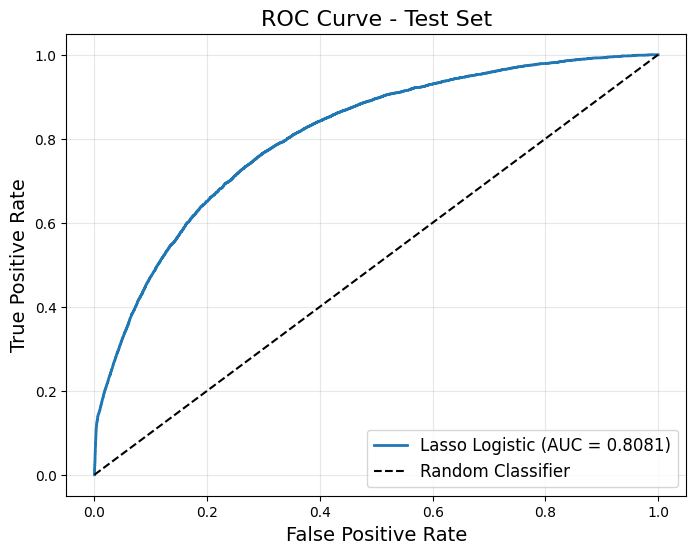

[CV 4/5] END ...........................C=0.001;, score=0.801 total time=   4.9s
[CV 4/5] END ............................C=0.01;, score=0.804 total time=  13.9s
[CV 3/5] END ...............................C=1;, score=0.798 total time= 2.5min
[CV 2/5] END .............................C=100;, score=0.806 total time= 2.1min
[CV 2/5] END ...........................C=0.001;, score=0.803 total time=   6.0s
[CV 1/5] END .............................C=0.1;, score=0.794 total time=  30.8s
[CV 5/5] END ...............................C=1;, score=0.797 total time= 2.4min
[CV 3/5] END .............................C=100;, score=0.798 total time= 2.0min
[CV 2/5] END ............................C=0.01;, score=0.806 total time=   8.5s
[CV 5/5] END .............................C=0.1;, score=0.797 total time= 1.6min
[CV 3/5] END ..............................C=10;, score=0.798 total time= 1.9min
[CV 5/5] END .............................C=100;, score=0.797 total time= 1.7min
[CV 3/5] END ...............

In [402]:
# 8. Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Lasso Logistic (AUC = {test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve - Test Set', fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [411]:
print(best_model.coef_.size, best_model.coef_)

39 [[ 0.          0.          0.13719225  0.02238277  0.          0.06401145
   0.01017687  0.08292061 -0.08052667  0.07576219  0.04414788  0.25803835
   0.          0.91240396  0.          0.          0.1595789  -0.05181909
  -0.02494058  0.         -0.09573993 -0.10730371  0.00349609  0.
   0.         -0.01758549  0.03817275 -0.00618941 -0.00136763 -0.02860555
   0.         -0.18307813 -0.01621348 -0.02174438  0.          0.
   0.          0.          0.        ]]


In [407]:
Passes_copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,0,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [422]:
training_features = X.columns.tolist()

In [430]:
Passes_copy[training_features]

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,0,0,0,0,61.0,40.1,60.2,40.7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,0,0,0,0,60.5,42.1,52.4,41.6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,0,0,0,0,53.1,42.3,33.2,60.9,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,0,0,0,0,33.4,59.7,28.5,31.1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,0,0,0,0,28.5,33.9,26.8,60.2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,0,0,0,0,76.6,62.0,82.6,52.3,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,0,0,0,0,81.6,80.0,84.6,63.0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,0,0,0,0,83.9,62.2,72.6,47.2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,0,0,0,0,77.1,33.1,80.3,17.9,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [431]:
X_full = Passes_copy[training_features].copy()

In [432]:
X_full_scaled = scaler.transform(X_full)

In [433]:
prob_shot_given_pass = best_model.predict_proba(X_full_scaled)[:, 1]

# Add to Passes_copy
Passes_copy['prob_shot_given_pass'] = prob_shot_given_pass

In [434]:
Passes_copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,prob_shot_given_pass
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0.022129
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.024044
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.011633
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.008124
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.007272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0.101494
1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.051527
1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.077104
1313773,0,-1.363300,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,0,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.092755


In [450]:
Shots.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp
143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.287115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c0218ff0-32e8-46de-8ed4-a22e7ee4fd48,143,NaN,"[101.8, 49.1]",3753972,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Dan Gosling,3343.0,Left Defensive Midfield,8,AFC Bournemouth,28,"[03020beb-adb6-401a-8beb-c21a4c493f5c, 5c874ed...",11,NaN,Left Foot,"[120.0, 33.2, 3.1]",True,"[{'location': [101.3, 51.7], 'player': {'id': ...",e38f4438-699d-42c3-befb-4762a172c6c3,NaN,Off T,0.115552,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:03:11.382000,Shot,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:03:11.382000
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.048003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d87ec24d-e894-4033-a1c3-85da30039ec6,366,NaN,"[80.9, 43.8]",3753972,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Dan Gosling,3343.0,Left Defensive Midfield,24,AFC Bournemouth,28,"[1e76b183-74be-44d8-9c63-53de7c9481ba, 7355d1d...",38,NaN,Right Foot,"[81.7, 43.7]",NaN,"[{'location': [117.4, 40.4], 'player': {'id': ...",6cebddd1-0ec1-4a2c-a0d3-a58d87fe0fbb,NaN,Blocked,0.006542,Half Volley,Open Play,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:08:38.577000,Shot,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:08:38.577000
415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.745855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71a9e4f9-5755-4040-8756-18b4b76f77a0,415,NaN,"[111.9, 39.9]",3753972,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Joshua King,3346.0,Center Forward,26,AFC Bournemouth,28,[369513fa-8903-4d3b-96a4-39eca3e4edb5],47,NaN,Right Foot,

In [447]:
Shots[['id','index','location','match_id','timestamp','period','player_id','player','possession_team','shot_outcome']]['shot_outcome'].value_counts().sum()

9908

In [452]:
Shots[['id','index','location','match_id','timestamp','period','player_id','player','possession_team','shot_outcome']]

,id,index,location,match_id,timestamp,period,player_id,player,possession_team,shot_outcome
143,c0218ff0-32e8-46de-8ed4-a22e7ee4fd48,143,"[101.8, 49.1]",3753972,0 days 00:03:11.382000,1,3343.0,Dan Gosling,AFC Bournemouth,Off T
366,d87ec24d-e894-4033-a1c3-85da30039ec6,366,"[80.9, 43.8]",3753972,0 days 00:08:38.577000,1,3343.0,Dan Gosling,AFC Bournemouth,Blocked
415,71a9e4f9-5755-4040-8756-18b4b76f77a0,415,"[111.9, 39.9]",3753972,0 days 00:09:47.445000,1,3346.0,Joshua King,AFC Bournemouth,Goal
435,fcd48d58-d7a0-4617-b9d1-ee005e016484,435,"[106.6, 28.7]",3753972,0 days 00:11:05.741000,1,3449.0,Wayne Routledge,Swansea City,Saved
440,a301cbf2-b1f7-474f-92f6-5b480c87287d,440,"[112.4, 48.6]",3753972,0 days 00:11:37.263000,1,4726.0,Kyle Bartley,Swansea City,Wayward
...,...,...,...,...,...,...,...,...,...,...
1313407,cd4e416a-8641-42cd-92db-fe5c6945ee2a,2768,"[112.2, 34.7]",3754351,0 days 00:36:16.359000,2,3407.0,Scott Dann,Crystal Palace,Saved
1313411,a7f4145e-6013-451d-991c-55ebd13e11c4,2772,"[114.3, 34.7]",3754351,0 days 00:36:17.522000,2,3407.0,Scott Dann,Crystal Palace,Goal
1313463,f29354e3-66b4-42f3-ba4b-7a4d617e850c,2824,"[92.2, 30.6]",3754351,0 days 00:38:22.017000,2,3501.0,Philippe Coutinho Correia,Liverpool,Blocked
1313548,f43eda39-97c0-4109-9483-a29d3fe05160,2909,"[98.9, 29.2]",3754351,0 days 00:40:01.657000,2,3501.0,Philippe Coutinho Correia,Liverpool,Saved


In [460]:
Shots[Shots['shot_outcome'] == 'Goal'][['id','index','location','match_id','timestamp','period','player_id','player','possession_team','shot_outcome']]

,id,index,location,match_id,timestamp,period,player_id,player,possession_team,shot_outcome
415,71a9e4f9-5755-4040-8756-18b4b76f77a0,415,"[111.9, 39.9]",3753972,0 days 00:09:47.445000,1,3346.0,Joshua King,AFC Bournemouth,Goal
1061,ea41074c-9b8f-4276-9228-c4f6930af5ca,1061,"[107.1, 40.0]",3753972,0 days 00:25:38.876000,1,3343.0,Dan Gosling,AFC Bournemouth,Goal
1101,d0069522-abf4-4466-9aa3-a352103cef44,1101,"[113.1, 37.4]",3753972,0 days 00:27:05.203000,1,3347.0,André Ayew Pelé,Swansea City,Goal
1397,8f2cb467-bd16-435b-b344-89447a21bff3,1397,"[108.1, 40.1]",3753972,0 days 00:38:17.830000,1,3057.0,Jonjo Shelvey,Swansea City,Goal
4394,f58ea4a3-e524-4bfc-8c55-d38765dfe82e,712,"[96.3, 29.5]",3753973,0 days 00:16:14.078000,1,3595.0,Manuel Lanzini,West Ham United,Goal
...,...,...,...,...,...,...,...,...,...,...
1303962,ad393f88-c83e-4c6a-85e6-5f6147bc4390,289,"[114.4, 50.1]",3754349,0 days 00:06:47.017000,1,3349.0,Michail Antonio,West Ham United,Goal
1307658,66b92fca-5258-4e04-95c5-1489ea3c5a11,509,"[118.7, 42.3]",3754350,0 days 00:13:47.146000,1,4041.0,José Salomón Rondón Giménez,West Bromwich Albion,Goal
1311411,e1e1421e-aad8-4c9c-8db4-1172030bc3dc,772,"[106.4, 42.8]",3754351,0 days 00:20:03.580000,1,3589.0,Yannick Bolasie Yala,Crystal Palace,Goal
1312086,83b14b7b-3f95-48ad-a3db-70f79048f6f2,1447,"[109.0, 32.6]",3754351,0 days 00:41:24.875000,1,3501.0,Philippe Coutinho Correia,Liverpool,Goal


In [520]:
passes_within_15s_shot_df[passes_within_15s_shot_df.linked_shot_id == '71a9e4f9-5755-4040-8756-18b4b76f77a0']

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp,linked_shot_time,linked_shot_index,linked_shot_id
404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.532810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2467eef-7952-478d-b79c-b0de68fd0e00,404,NaN,"[49.1, 19.4]",3753972,9,NaN,NaN,NaN,NaN,-0.264207,NaN,Left Foot,NaN,NaN,NaN,"[69.8, 13.8]",High Pass,NaN,21.444113,NaN,NaN,Junior Stanislas,3463.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Charlie Daniels,3345.0,Left Back,26,AFC Bournemouth,28,[7c346c7c-8055-4371-9e6c-3cba4c93afca],38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:09:38.292000,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:09:38.292000,0 days 00:09:47.445000,415,71a9e4f9-5755-4040-8756-18b4b76f77a0
413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.284867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d4bb0c4c-3bcf-4a80-bb89-c4912f9a6d92,413,NaN,"[112.3, 22.1]",3753972,9,NaN,NaN,NaN,NaN,1.613551,71a9e4f9-5755-4040-8756-18b4b76f77a0,Left Foot,True,NaN,NaN,"[111.5, 40.8]",Ground Pass,NaN,18.717104,NaN,NaN,Joshua King,3346.0,NaN,NaN,NaN,NaN,Recovery,1,Regular Play,Junior Stanislas,3463.0,Left Midfield,26,AFC Bournemouth,28,"[0ca637c9-ea29-4984-afc7-4272946b519e, b35247b...",46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:09:46.137000,Pass,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:09:46.137000,0 days 00:09:47.445000,415,71a9e4f9-5755-4040-8756-18b4b76f77a0


In [530]:
passes_within_15s_shot_df.linked_shot_id.isin(goal_id).value_counts()

linked_shot_id
False    22678
True      2581
Name: count, dtype: int64

In [538]:
goal_id.isin(passes_within_15s_shot_df.linked_shot_id).value_counts()
#a lot of these False ones are penalties 

id
True     837
False    151
Name: count, dtype: int64

In [607]:
df[df.id == '8f2cb467-bd16-435b-b344-89447a21bff3']

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp
1397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.763846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8f2cb467-bd16-435b-b344-89447a21bff3,1397,NaN,"[108.1, 40.1]",3753972,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Other,Jonjo Shelvey,3057.0,Center Attacking Midfield,69,Swansea City,26,[23d79155-53e0-4dcc-86d3-f51c22c79900],17,NaN,Right Foot,"[120.0, 43.8, 0.2]",NaN,NaN,NaN,NaN,Goal,0.7835,Normal,Penalty,NaN,NaN,NaN,NaN,NaN,Swansea City,26,0 days 00:38:17.830000,Shot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:38:17.830000


In [533]:
passes_within_15s_shot_df.shape

(25259, 122)

In [536]:
goal_id

415        71a9e4f9-5755-4040-8756-18b4b76f77a0
1061       ea41074c-9b8f-4276-9228-c4f6930af5ca
1101       d0069522-abf4-4466-9aa3-a352103cef44
1397       8f2cb467-bd16-435b-b344-89447a21bff3
4394       f58ea4a3-e524-4bfc-8c55-d38765dfe82e
                           ...                 
1303962    ad393f88-c83e-4c6a-85e6-5f6147bc4390
1307658    66b92fca-5258-4e04-95c5-1489ea3c5a11
1311411    e1e1421e-aad8-4c9c-8db4-1172030bc3dc
1312086    83b14b7b-3f95-48ad-a3db-70f79048f6f2
1313411    a7f4145e-6013-451d-991c-55ebd13e11c4
Name: id, Length: 988, dtype: object

In [456]:
Passes_copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,prob_shot_given_pass
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0.022129
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.024044
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.011633
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.008124
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.007272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0.101494
1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.051527
1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.077104
1313773,0,-1.363300,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,0,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.092755


In [597]:
passes_within_15s_shot_df

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp,linked_shot_time,linked_shot_index,linked_shot_id
126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.834888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2be51e25-52b7-4761-9582-198b2cad5b2b,126,NaN,"[56.0, 67.4]",3753972,3,NaN,NaN,NaN,NaN,-1.715838,NaN,Right Foot,NaN,NaN,NaN,"[54.7, 58.5]",Low Pass,NaN,8.994443,NaN,NaN,Andrew Surman,3344.0,NaN,NaN,NaN,NaN,Recovery,1,Regular Play,Matt Ritchie,3049.0,Right Midfield,8,AFC Bournemouth,28,"[1e0769b7-2491-4f0b-be25-183d7f2ecc3a, 2b2352f...",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:03:00.561000,Pass,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:03:00.561000,0 days 00:03:11.382000,143,c0218ff0-32e8-46de-8ed4-a22e7ee4fd48
128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.675914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ddd7b7a2-dae5-4477-8ec6-7f29487f1de5,128,NaN,"[54.7, 58.5]",3753972,3,NaN,NaN,NaN,NaN,0.501906,NaN,Left Foot,NaN,NaN,NaN,"[62.9, 63.0]",Low Pass,NaN,9.353609,NaN,NaN,Dan Gosling,3343.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Andrew Surman,3344.0,Right Defensive Midfield,8,AFC Bournemouth,28,[b64596d1-5c8a-424a-b30b-5aca5425e7dd],1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:03:01.396000,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:03:01.396000,0 days 00:03:11.382000,143,c0218ff0-32e8-46de-8ed4-a22e7ee4fd48
132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.992215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84a172ad-62f4-4ef2-bc32-862501cdc23b,132,NaN,"[62.9, 63.0]",3753972,3,NaN,NaN,NaN,NaN,-0.536146,NaN,Right Foot,NaN,NaN,NaN,"[76.7, 54.8]",Ground Pass,NaN,16.052414,NaN,NaN,Joshua King,3346.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Dan Gosling,3343.0,Left Defensive Midfield,8,AFC Bournemou

In [610]:
passes_within_15s_shot_df['goal']=0
passes_within_15s_shot_df['goal']=passes_within_15s_shot_df['goal'].mask(passes_within_15s_shot_df['linked_shot_id'].isin(goal_id),1)
#passes_within_15s_shot_df['linked_shot_id'].isin(goal_id)

In [614]:
Passes_copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,prob_shot_given_pass
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0.022129
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.024044
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.011633
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.008124
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.007272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0.101494
1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.051527
1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.077104
1313773,0,-1.363300,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,0,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.092755


In [630]:
passes_within_15s_shot_df[passes_within_15s_shot_df['goal'] == 1].index


Index([    404,     413,    1046,    1048,    1053,    1056,    1059,    1085,
          1088,    4379,
       ...
       1303960, 1307652, 1307655, 1311394, 1312073, 1312075, 1312079, 1312081,
       1312084, 1313404],
      dtype='int64', length=2581)

In [639]:
Passes_copy.index

Index([      5,       7,      11,      14,      17,      20,      23,      26,
            28,      30,
       ...
       1313730, 1313742, 1313744, 1313751, 1313760, 1313762, 1313767, 1313770,
       1313773, 1313776],
      dtype='int64', length=282379)

In [657]:

Passes_copy['within_15s_goal'] = 0
Passes_copy['within_15s_goal'] = Passes_copy['within_15s_goal'].mask(
    Passes_copy.index.isin(
        passes_within_15s_shot_df[passes_within_15s_shot_df['goal'] == 1].index
    ),
    1
)

In [658]:
Passes_copy['within_15s_goal'].value_counts()

within_15s_goal
0    279798
1      2581
Name: count, dtype: int64

In [665]:
Passes_copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,prob_shot_given_pass,within_15s_goal
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0.022129,0
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.024044,0
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.011633,0
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.008124,0
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.007272,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,NaN,0,Divock Okoth Origi,4747.0,0,0,0,0,3754351,93,76.6,62.0,82.6,52.3,3380.0,Christian Benteke Liolo,Center Forward,Liverpool,Pass,0 days 01:33:38.680000,0,48.657579,39.370674,9.286905,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0.101494,0
1313767,0,-1.396124,0,0,0,0,17.262676,NaN,0,Adam David Lallana,4090.0,0,0,0,0,3754351,93,81.6,80.0,84.6,63.0,4590.0,Nathaniel Edwin Clyne,Right Back,Liverpool,Pass,0 days 01:33:46.187000,0,55.448715,42.215637,13.233078,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.051527,0
1313770,0,-2.216427,0,0,0,0,18.780043,NaN,0,Lucas Pezzini Leiva,7780.0,0,0,0,0,3754351,93,83.9,62.2,72.6,47.2,4090.0,Adam David Lallana,Center Attacking Midfield,Liverpool,Pass,0 days 01:33:47.847000,0,42.379830,47.943717,-5.563887,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.077104,0
1313773,0,-1.363300,0,0,0,0,15.533191,NaN,0,Alberto Moreno Pérez,3515.0,0,0,0,0,3754351,93,77.1,33.1,80.3,17.9,7780.0,Lucas Pezzini Leiva,Left Center Midfield,Liverpool,Pass,0 days 01:33:51.331000,0,43.451352,45.436769,-1.985417,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.092755,0


In [673]:
#Model 2 


In [678]:
Log_Reg_Passes_Copy = pd.concat([Log_Reg_Passes_Copy,Passes_copy['within_15s_goal']],axis=1)

In [679]:
Log_Reg_Passes_Copy

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,within_15s_shot,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,within_15s_goal
5,0,2.498092,0,0,0,0,1.000000,0,0,0,0,61.0,40.1,60.2,40.7,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
7,0,-3.079943,0,0,0,0,8.115417,0,0,0,0,60.5,42.1,52.4,41.6,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
11,0,2.389948,0,0,0,0,27.239126,0,0,0,0,53.1,42.3,33.2,60.9,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
14,0,-1.740478,0,0,0,0,29.016720,0,0,0,0,33.4,59.7,28.5,31.1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
17,0,1.635345,0,0,0,0,26.354885,0,0,0,0,28.5,33.9,26.8,60.2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,0,0,0,0,76.6,62.0,82.6,52.3,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,0,0,0,0,81.6,80.0,84.6,63.0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
1313770,0,-2.216427,0,0,0,0,18.780043,0,0,0,0,83.9,62.2,72.6,47.2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,0,0,0,0,77.1,33.1,80.3,17.9,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [680]:
X = Log_Reg_Passes_Copy.drop(columns=['within_15s_shot','within_15s_goal'])

In [681]:
X

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,0,0,0,0,61.0,40.1,60.2,40.7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,0,0,0,0,60.5,42.1,52.4,41.6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,0,0,0,0,53.1,42.3,33.2,60.9,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,0,0,0,0,33.4,59.7,28.5,31.1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,0,0,0,0,28.5,33.9,26.8,60.2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,0,0,0,0,76.6,62.0,82.6,52.3,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,0,0,0,0,81.6,80.0,84.6,63.0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,0,0,0,0,83.9,62.2,72.6,47.2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,0,0,0,0,77.1,33.1,80.3,17.9,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [682]:
y = Log_Reg_Passes_Copy['within_15s_goal']

In [683]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=123,
    stratify=y  # Keep same class distribution
)

In [684]:
print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")


Train size: 197665
Test size: 84714


In [685]:
# 2. Scale the features (IMPORTANT for Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#NEXT TIME ONLY SCALE NON CATEGORICAL/BINARY VARIABLES 

In [686]:
# 3. Set up Lasso Logistic Regression with 5-fold CV to find best C
# Note: C is the INVERSE of regularization strength
# Smaller C = stronger penalty (more regularization)
# Larger C = weaker penalty (less regularization)
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]  # Test different penalty strengths
}

lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',  # Required for L1
    max_iter=1000,
    random_state=123
)

# GridSearchCV performs 5-fold cross-validation on TRAINING data only
grid_search = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for AUC
    n_jobs=-1,  # Use all CPU cores
    verbose=3
)

print("\n" + "="*50)
print("Running 5-fold CV to find optimal C parameter...")
print("="*50)

# Fit on training data only
grid_search.fit(X_train_scaled, y_train)


Running 5-fold CV to find optimal C parameter...
Fitting 5 folds for each of 7 candidates, totalling 35 fits


,estimator,LogisticRegre...r='liblinear')
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [687]:
print("\n" + "="*50)
print("Cross-Validation Results:")
print("="*50)
print(f"\nBest C parameter: {grid_search.best_params_['C']}")
print(f"Best CV AUC score: {grid_search.best_score_:.4f}")


Cross-Validation Results:

Best C parameter: 0.1
Best CV AUC score: 0.7878


In [688]:


# Show all CV results
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nAll CV results:")
print(cv_results[['param_C', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False))

# 5. Get the best model (already fitted on full training set)
best_model = grid_search.best_estimator_


All CV results:
    param_C  mean_test_score  std_test_score
2     0.100         0.787773        0.005679
3     1.000         0.787350        0.005732
4    10.000         0.787215        0.005725
5   100.000         0.787184        0.005711
6  1000.000         0.787182        0.005711
1     0.010         0.787171        0.005984
0     0.001         0.778779        0.006020


In [689]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

In [690]:
feature_importance

,feature,coefficient
13,end_x,0.977158
31,pass_type_Throw-in,-0.176464
29,pass_type_Kick Off,-0.134101
16,From Counter,0.131386
2,pass_cross,0.121042
32,body_part_Drop Kick,-0.103340
9,pass_through_ball,0.088361
21,From Throw In,-0.075691
11,x,0.070272
8,pass_switch,-0.058279


In [691]:
# 7. Evaluate on TEST SET (the held-out 30%)
print("\n" + "="*50)
print("Test Set Performance:")
print("="*50)

# Predict probabilities
y_test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = best_model.predict(X_test_scaled)

# Calculate AUC
test_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"\nTest AUC: {test_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

#I believe better model would be to use xG as target variable as Goal rarer, and more nosiy 


Test Set Performance:

Test AUC: 0.8005

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     83940
           1       0.43      0.00      0.01       774

    accuracy                           0.99     84714
   macro avg       0.71      0.50      0.50     84714
weighted avg       0.99      0.99      0.99     84714


Confusion Matrix:
[[83936     4]
 [  771     3]]


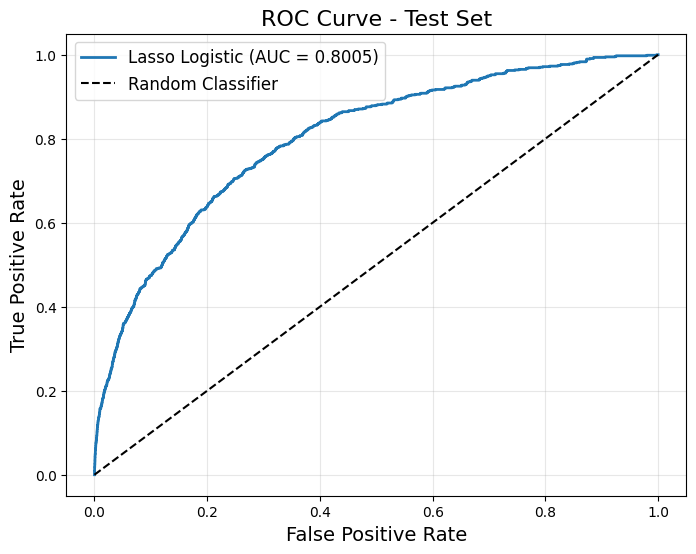

In [693]:
# 8. Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Lasso Logistic (AUC = {test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve - Test Set', fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [694]:
training_features = X.columns.tolist()
Passes_copy[training_features]

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,0,0,0,0,61.0,40.1,60.2,40.7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,0,0,0,0,60.5,42.1,52.4,41.6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,0,0,0,0,53.1,42.3,33.2,60.9,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,0,0,0,0,33.4,59.7,28.5,31.1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,0,0,0,0,28.5,33.9,26.8,60.2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,0,0,0,0,76.6,62.0,82.6,52.3,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,0,0,0,0,81.6,80.0,84.6,63.0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,0,0,0,0,83.9,62.2,72.6,47.2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,0,0,0,0,77.1,33.1,80.3,17.9,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [695]:
X_full = Passes_copy[training_features].copy()


In [696]:
X_full_scaled = scaler.transform(X_full)

In [697]:
prob_goal_given_pass = best_model.predict_proba(X_full_scaled)[:, 1]

# Add to Passes_copy
Passes_copy['prob_goal_given_pass'] = prob_goal_given_pass

In [699]:
Passes_copy.head()

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,prob_shot_given_pass,within_15s_goal,prob_goal_given_pass
5,0,2.498092,0,0,0,0,1.000000,NaN,0,Jonjo Shelvey,3057.0,0,0,0,0,3753972,0,61.0,40.1,60.2,40.7,15996.0,Éderzito António Macedo Lopes,Center Forward,Swansea City,Pass,0 days 00:00:00.548000,0,59.000085,59.804097,-0.804012,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0.022129,0,0.000852
7,0,-3.079943,0,0,0,0,8.115417,NaN,0,Leon Britton,4631.0,0,0,0,0,3753972,0,60.5,42.1,52.4,41.6,3057.0,Jonjo Shelvey,Center Attacking Midfield,Swansea City,Pass,0 days 00:00:00.898000,0,59.537047,67.618932,-8.081885,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.024044,0,0.003474
11,0,2.389948,0,0,0,0,27.239126,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,53.1,42.3,33.2,60.9,4631.0,Leon Britton,Right Defensive Midfield,Swansea City,Pass,0 days 00:00:02.683000,0,66.939525,89.280737,-22.341212,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.011633,0,0.001574
14,0,-1.740478,0,0,0,0,29.016720,NaN,0,Ashley Williams,3644.0,0,0,0,0,3753972,0,33.4,59.7,28.5,31.1,4726.0,Kyle Bartley,Right Center Back,Swansea City,Pass,0 days 00:00:05.470000,0,88.812443,91.931823,-3.119380,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.008124,0,0.001221
17,0,1.635345,0,0,0,0,26.354885,NaN,0,Kyle Bartley,4726.0,0,0,0,0,3753972,0,28.5,33.9,26.8,60.2,3644.0,Ashley Williams,Left Center Back,Swansea City,Pass,0 days 00:00:08.436000,0,91.703108,95.363934,-3.660827,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.007272,0,0.001152


In [703]:
Passes_copy['xD'] = Passes_copy['prob_shot_given_pass'] * Passes_copy['prob_goal_given_pass']
Passes_copy.sort_values('xD', ascending = False)

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,prob_shot_given_pass,within_15s_goal,prob_goal_given_pass,xD
294542,0,1.366375,1,0,0,0,16.748732,NaN,0,Gerard Deulofeu Lázaro,3726.0,0,1,0,0,3754056,70,113.7,24.2,117.1,40.6,4275.0,Ross Barkley,Right Center Midfield,Everton,Pass,0 days 01:10:10.757000,1,17.009703,2.961419,14.048285,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.989935,1,0.864004,8.553082e-01
1091850,0,-0.835684,1,0,0,0,32.355680,NaN,0,Diego da Silva Costa,5198.0,0,1,0,0,3754287,64,86.7,72.5,108.4,48.5,3472.0,Willian Borges da Silva,Right Wing,Chelsea,Pass,0 days 01:04:32.763000,1,46.531065,14.380890,32.150175,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.982406,1,0.799855,7.857828e-01
1099711,0,-0.124870,0,0,0,0,24.087550,NaN,0,Danny Drinkwater,3662.0,0,1,0,0,3754290,10,93.9,31.3,117.8,28.3,3814.0,Riyad Mahrez,Right Midfield,Leicester City,Pass,0 days 00:10:08.877000,1,27.511816,11.905041,15.606775,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.951833,0,0.630140,5.997874e-01
64064,0,0.019321,0,0,0,0,20.703865,NaN,0,Olivier Giroud,3604.0,0,1,0,0,3753990,8,92.4,52.4,113.1,52.8,3385.0,Alexis Alejandro Sánchez Sánchez,Right Wing,Arsenal,Pass,0 days 00:08:15.737000,1,30.257561,14.541320,15.716241,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.942644,0,0.556131,5.242331e-01
816043,0,-0.181965,0,0,0,0,12.709839,NaN,0,Philippe Coutinho Correia,3501.0,0,1,0,0,3754208,31,96.1,25.0,108.6,22.7,3493.0,Emre Can,Left Center Midfield,Liverpool,Pass,0 days 00:31:37.413000,1,28.217193,20.718349,7.498844,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.935267,1,0.546500,5.111235e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587073,0,-1.695151,0,0,0,0,29.024128,NaN,0,Petr Čech,3461.0,0,0,0,0,3754141,93,7.4,80.0,3.8,51.2,3475.0,Per Mertesacker,Right Center Back,Arsenal,Pass,0 days 01:33:43.636000,0,119.493766,116.738511,2.755254,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.001487,0,0.000166,2.472156e-07
122555,0,-1.692768,0,0,0,0,15.616017,NaN,0,Craig Dawson,3523.0,0,0,0,0,3754006,90,5.3,80.0,3.4,64.5,3490.0,James Morrison,Right Center Midfield,West Bromwich Albion,Pass,0 days 01:30:56.498000,0,121.474648,119.146171,2.328477,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.001420,0,0.000173,2.456997e-07
758493,0,-1.598000,0,0,0,0,14.705441,NaN,0,Maya Yoshida,3300.0,0,0,0,0,3754191,58,4.0,80.0,3.6,65.3,3329.0,Cédric Ricardo Alves Soares,Right Back,Southampton,Pass,0 days 00:58:27.580000,0,122.702893,119.117799,3.585094,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.001411,0,0.000174,2.456654e-07
384735,0,-2.330226,0,0,0,0,10.893117,NaN,0,John Stones,3244.0,0,0,0,0,3754082,85,8.7,80.0,1.2,72.1,4589.0,Séamus Coleman,Right Back,Everton,Pass,0 days 01:25:39.426000,0,118.269565,123.060351,-4.790786,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.001354,0,0.000157,2.132412e-07


[CV 3/5] END ............................C=0.01;, score=0.776 total time=   7.9s
[CV 1/5] END ...............................C=1;, score=0.792 total time=  25.9s
[CV 4/5] END ..............................C=10;, score=0.793 total time= 4.4min
[CV 2/5] END ............................C=0.01;, score=0.789 total time=   6.9s
[CV 4/5] END .............................C=0.1;, score=0.794 total time=  21.2s
[CV 3/5] END ..............................C=10;, score=0.777 total time= 4.6min
[CV 1/5] END ...........................C=0.001;, score=0.781 total time=   3.0s
[CV 4/5] END ............................C=0.01;, score=0.794 total time=   6.3s
[CV 2/5] END ...............................C=1;, score=0.788 total time=  34.8s
[CV 1/5] END .............................C=100;, score=0.792 total time= 4.7min
[CV 2/5] END ...........................C=0.001;, score=0.780 total time=   3.7s
[CV 3/5] END .............................C=0.1;, score=0.778 total time=  17.3s
[CV 5/5] END ...............

In [ ]:
#model 2 updated/alternative (conditional - running model only looking at passes that resulted in shot_within_15s)

In [793]:
Log_Reg_Passes_Copy[Log_Reg_Passes_Copy['within_15s_shot'] == 1]

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,within_15s_shot,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,within_15s_goal
126,0,-1.715838,0,0,0,0,8.994443,0,0,0,0,56.0,67.4,54.7,58.5,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
128,0,0.501906,0,0,0,0,9.353609,0,0,0,0,54.7,58.5,62.9,63.0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
132,0,-0.536146,0,0,0,0,16.052414,0,0,0,0,62.9,63.0,76.7,54.8,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
136,0,0.903131,0,0,0,0,13.243867,0,0,0,0,86.1,28.7,94.3,39.1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
140,0,1.471946,0,0,0,0,12.159359,0,0,0,0,99.5,38.6,100.7,50.7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313404,0,-1.727398,0,0,0,0,42.317844,1,1,0,0,120.0,80.0,113.4,38.2,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1313451,0,-0.848897,0,0,0,0,12.257650,0,0,0,0,46.3,13.2,54.4,4.0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1313460,0,-0.872676,0,0,0,0,11.356936,0,0,0,0,64.2,20.0,71.5,11.3,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1313543,0,-0.505581,0,0,0,0,25.603125,0,0,0,0,55.9,62.2,78.3,49.8,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


In [794]:
X = Log_Reg_Passes_Copy[Log_Reg_Passes_Copy['within_15s_shot'] == 1].drop(columns=['within_15s_shot','within_15s_goal'])

In [795]:
X

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
126,0,-1.715838,0,0,0,0,8.994443,0,0,0,0,56.0,67.4,54.7,58.5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0
128,0,0.501906,0,0,0,0,9.353609,0,0,0,0,54.7,58.5,62.9,63.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
132,0,-0.536146,0,0,0,0,16.052414,0,0,0,0,62.9,63.0,76.7,54.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
136,0,0.903131,0,0,0,0,13.243867,0,0,0,0,86.1,28.7,94.3,39.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
140,0,1.471946,0,0,0,0,12.159359,0,0,0,0,99.5,38.6,100.7,50.7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313404,0,-1.727398,0,0,0,0,42.317844,1,1,0,0,120.0,80.0,113.4,38.2,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1313451,0,-0.848897,0,0,0,0,12.257650,0,0,0,0,46.3,13.2,54.4,4.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1313460,0,-0.872676,0,0,0,0,11.356936,0,0,0,0,64.2,20.0,71.5,11.3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1313543,0,-0.505581,0,0,0,0,25.603125,0,0,0,0,55.9,62.2,78.3,49.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [796]:
y = Log_Reg_Passes_Copy[Log_Reg_Passes_Copy['within_15s_shot'] == 1]['within_15s_goal']

In [797]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=123,
    stratify=y  # Keep same class distribution
)

In [798]:
print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")


Train size: 16695
Test size: 7155


In [799]:
# 2. Scale the features (IMPORTANT for Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#NEXT TIME ONLY SCALE NON CATEGORICAL/BINARY VARIABLES 

In [800]:
# 3. Set up Lasso Logistic Regression with 5-fold CV to find best C
# Note: C is the INVERSE of regularization strength
# Smaller C = stronger penalty (more regularization)
# Larger C = weaker penalty (less regularization)
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]  # Test different penalty strengths
}

lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',  # Required for L1
    max_iter=1000,
    random_state=123
)

# GridSearchCV performs 5-fold cross-validation on TRAINING data only
grid_search = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for AUC
    n_jobs=-1,  # Use all CPU cores
    verbose=3
)

print("\n" + "="*50)
print("Running 5-fold CV to find optimal C parameter...")
print("="*50)

# Fit on training data only
grid_search.fit(X_train_scaled, y_train)


Running 5-fold CV to find optimal C parameter...
Fitting 5 folds for each of 7 candidates, totalling 35 fits


,estimator,LogisticRegre...r='liblinear')
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [801]:
print("\n" + "="*50)
print("Cross-Validation Results:")
print("="*50)
print(f"\nBest C parameter: {grid_search.best_params_['C']}")
print(f"Best CV AUC score: {grid_search.best_score_:.4f}")


Cross-Validation Results:

Best C parameter: 0.01
Best CV AUC score: 0.5540


In [802]:


# Show all CV results
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nAll CV results:")
print(cv_results[['param_C', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False))

# 5. Get the best model (already fitted on full training set)
best_model = grid_search.best_estimator_


All CV results:
    param_C  mean_test_score  std_test_score
1     0.010         0.553977        0.003495
6  1000.000         0.549152        0.010886
5   100.000         0.549144        0.010885
4    10.000         0.549131        0.010906
3     1.000         0.548357        0.010640
2     0.100         0.545039        0.011736
0     0.001         0.500000        0.000000


In [803]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

In [804]:
feature_importance

,feature,coefficient
9,pass_through_ball,0.125774
2,pass_cross,0.077924
16,From Counter,0.044372
13,end_x,0.013242
0,pass_aerial_won,0.000000
29,pass_type_Kick Off,0.000000
24,Low Pass,0.000000
25,pass_type_Corner,0.000000
26,pass_type_Free Kick,0.000000
27,pass_type_Goal Kick,0.000000


In [805]:
# 7. Evaluate on TEST SET (the held-out 30%)
print("\n" + "="*50)
print("Test Set Performance:")
print("="*50)

# Predict probabilities
y_test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = best_model.predict(X_test_scaled)

# Calculate AUC
test_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"\nTest AUC: {test_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

#I believe better model would be to use xG as target variable as Goal rarer, and more nosiy 


Test Set Performance:

Test AUC: 0.5302

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6381
           1       0.00      0.00      0.00       774

    accuracy                           0.89      7155
   macro avg       0.45      0.50      0.47      7155
weighted avg       0.80      0.89      0.84      7155


Confusion Matrix:
[[6381    0]
 [ 774    0]]


In [808]:
training_features = X.columns.tolist()
Passes_copy[training_features]

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outswinging,pass_switch,pass_through_ball,pass_straight,x,y,end_x,end_y,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown
5,0,2.498092,0,0,0,0,1.000000,0,0,0,0,61.0,40.1,60.2,40.7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
7,0,-3.079943,0,0,0,0,8.115417,0,0,0,0,60.5,42.1,52.4,41.6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
11,0,2.389948,0,0,0,0,27.239126,0,0,0,0,53.1,42.3,33.2,60.9,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
14,0,-1.740478,0,0,0,0,29.016720,0,0,0,0,33.4,59.7,28.5,31.1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
17,0,1.635345,0,0,0,0,26.354885,0,0,0,0,28.5,33.9,26.8,60.2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313762,0,-1.016844,0,0,0,0,11.405701,0,0,0,0,76.6,62.0,82.6,52.3,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1313767,0,-1.396124,0,0,0,0,17.262676,0,0,0,0,81.6,80.0,84.6,63.0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1313770,0,-2.216427,0,0,0,0,18.780043,0,0,0,0,83.9,62.2,72.6,47.2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1313773,0,-1.363300,0,0,0,0,15.533191,0,0,0,0,77.1,33.1,80.3,17.9,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [809]:
X_full = Passes_copy[training_features].copy()
X_full_scaled = scaler.transform(X_full)

In [810]:
prob_goal_given_pass = best_model.predict_proba(X_full_scaled)[:, 1]

# Add to Passes_copy
Passes_copy['prob_goal_given_pass'] = prob_goal_given_pass

In [811]:
Passes_copy['xD'] = Passes_copy['prob_shot_given_pass'] * Passes_copy['prob_goal_given_pass']
Passes_copy.sort_values('xD', ascending = False)

,pass_aerial_won,pass_angle,pass_cross,pass_cut_back,pass_deflected,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_switch,pass_through_ball,pass_straight,pass_no_touch,match_id,minute,x,y,end_x,end_y,player_id,player,position,team,type,game_timestamp,within_15s_shot,initial_dist_to_goal,post_dist_to_goal,dist_closer_to_goal,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play,Ground Pass,High Pass,Low Pass,pass_type_Corner,pass_type_Free Kick,pass_type_Goal Kick,pass_type_Interception,pass_type_Kick Off,pass_type_Recovery,pass_type_Standard Pass,pass_type_Throw-in,body_part_Drop Kick,body_part_Head,body_part_Keeper Arm,body_part_Left Foot,body_part_Other,body_part_Right Foot,body_part_Unknown,prob_shot_given_pass,within_15s_goal,prob_goal_given_pass,xD
294542,0,1.366375,1,0,0,0,16.748732,NaN,0,Gerard Deulofeu Lázaro,3726.0,0,1,0,0,3754056,70,113.7,24.2,117.1,40.6,4275.0,Ross Barkley,Right Center Midfield,Everton,Pass,0 days 01:10:10.757000,1,17.009703,2.961419,14.048285,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.989935,1,0.370052,0.366328
1091850,0,-0.835684,1,0,0,0,32.355680,NaN,0,Diego da Silva Costa,5198.0,0,1,0,0,3754287,64,86.7,72.5,108.4,48.5,3472.0,Willian Borges da Silva,Right Wing,Chelsea,Pass,0 days 01:04:32.763000,1,46.531065,14.380890,32.150175,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.982406,1,0.368757,0.362269
1099711,0,-0.124870,0,0,0,0,24.087550,NaN,0,Danny Drinkwater,3662.0,0,1,0,0,3754290,10,93.9,31.3,117.8,28.3,3814.0,Riyad Mahrez,Right Midfield,Leicester City,Pass,0 days 00:10:08.877000,1,27.511816,11.905041,15.606775,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.951833,0,0.303515,0.288896
64064,0,0.019321,0,0,0,0,20.703865,NaN,0,Olivier Giroud,3604.0,0,1,0,0,3753990,8,92.4,52.4,113.1,52.8,3385.0,Alexis Alejandro Sánchez Sánchez,Right Wing,Arsenal,Pass,0 days 00:08:15.737000,1,30.257561,14.541320,15.716241,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.942644,0,0.302881,0.285509
628935,0,0.864597,1,0,0,0,35.750244,NaN,0,James McArthur,3464.0,0,1,0,0,3754153,56,90.5,15.8,113.7,43.0,3589.0,Yannick Bolasie Yala,Left Center Forward,Crystal Palace,Pass,0 days 00:56:12.849000,1,38.156127,6.977822,31.178305,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0.912033,0,0.311313,0.283928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141431,0,-2.092631,0,0,0,0,9.228217,NaN,0,José Miguel da Rocha Fonte,3960.0,0,0,0,0,3754302,13,7.7,80.0,3.1,72.0,3329.0,Cédric Ricardo Alves Soares,Right Back,Southampton,Pass,0 days 00:13:36.938000,0,119.211115,121.200701,-1.989586,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.001432,0,0.103488,0.000148
122555,0,-1.692768,0,0,0,0,15.616017,NaN,0,Craig Dawson,3523.0,0,0,0,0,3754006,90,5.3,80.0,3.4,64.5,3490.0,James Morrison,Right Center Midfield,West Bromwich Albion,Pass,0 days 01:30:56.498000,0,121.474648,119.146171,2.328477,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.001420,0,0.103505,0.000147
758493,0,-1.598000,0,0,0,0,14.705441,NaN,0,Maya Yoshida,3300.0,0,0,0,0,3754191,58,4.0,80.0,3.6,65.3,3329.0,Cédric Ricardo Alves Soares,Right Back,Southampton,Pass,0 days 00:58:27.580000,0,122.702893,119.117799,3.585094,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.001411,0,0.103517,0.000146
929203,0,-1.652804,0,0,0,0,7.324616,NaN,0,James Tomkins,3316.0,0,0,0,0,3754241,33,4.2,80.0,3.6,72.7,3349.0,Michail Antonio,Right Wing Back,West Ham United,Pass,0 days 00:33:07.888000,0,122.513836,120.905955,1.607881,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.001405,0,0.103517,0.000145


In [704]:
import pandas as pd
from tqdm.auto import tqdm
from statsbombpy import sb


def get_minutes_played4(df, match_id, player_id, match_durations):
    """
    Calculates minutes played for a player in a match using pre-calculated match durations.

    Args:
        df (DataFrame): DataFrame of events for the match.
        match_id (int): Match ID.
        player_id (int): Player ID.
        match_durations (DataFrame): DataFrame containing pre-calculated durations for each match and period.

    Returns:
        float: Total minutes played by the player in the match.
    """

    df['timestamp'] = pd.to_timedelta(df['timestamp'])

    player_info_df = df[(df['match_id'] == match_id) & (df['player_id'] == player_id)]
    if player_info_df.empty:
        return 0  # If player not found in the match, assume 0 minutes played

    team = player_info_df['team'].iloc[0]
    player_name = player_info_df['player'].iloc[0]

    try:
        lineup = df[(df['match_id'] == match_id) & (df['team'] == team) & (df['type'] == 'Starting XI')]['tactics'].values[0]
        starting_xi = [x['player']['name'] for x in lineup['lineup']]
        starter = player_name in starting_xi
    except IndexError:
        return 0

    durations = {
        period: match_durations[
            (match_durations['match_id'] == match_id) & (match_durations['period'] == period)
        ]['duration_minutes'].values[0] if not match_durations[
            (match_durations['match_id'] == match_id) & (match_durations['period'] == period)
        ]['duration_minutes'].empty else 0
        for period in range(1, 5)
    }

    min_played = 0

    if starter:
        min_played = sum(durations.values())
    
    else:
        entered = df[
            (df['match_id'] == match_id) &
            (df['team'] == team) &
            (df['type'] == 'Substitution') &
            (df['substitution_replacement'] == player_name)  # Changed from player to player_name
        ][['timestamp', 'period']]
        if not entered.empty:
            entered_period = entered['period'].values[0]
            entered_time = pd.Timedelta(entered['timestamp'].values[0]).total_seconds() / 60
            min_played = sum(durations[p] for p in range(entered_period+1, 5))  # Time in future periods
            min_played += (durations[entered_period] - entered_time) if entered_period in durations else 0  # Time in current period
    


    was_sub = df[
        (df['match_id'] == match_id) &
        (df['team'] == team) &
        (df['player_id'] == player_id) &
        (df['type'] == 'Substitution')
    ][['timestamp', 'period']]
    if not was_sub['timestamp'].empty:
        sub_period = was_sub['period'].values[0]
        sub_time = pd.Timedelta(was_sub['timestamp'].values[0]).total_seconds() / 60
        time_remaining_in_sub_period = durations[sub_period] - sub_time if sub_period in durations else 0
        min_played -= time_remaining_in_sub_period
        min_played -= sum(durations[p] for p in range(sub_period + 1, 5))

    was_excluded = df[
        (df['match_id'] == match_id) &
        (df['team'] == team) &
        (df['player_id'] == player_id) &
        (df.apply(lambda row: (
            row.get('bad_behaviour', {}).get('card', {}).get('name') in ['Red Card', 'Second Yellow'] or
            row.get('foul_committed', {}).get('card', {}).get('name') in ['Red Card', 'Second Yellow']
        ), axis=1))
    ][['timestamp', 'period']]
    if not was_excluded['timestamp'].empty:
        exclusion_period = was_excluded['period'].values[0]
        exclusion_time = was_excluded['timestamp'].values[0].total_seconds() / 60
        time_remaining_in_exclusion_period = durations[exclusion_period] - exclusion_time if exclusion_period in durations else 0
        min_played -= time_remaining_in_exclusion_period
        min_played -= sum(durations[p] for p in range(exclusion_period + 1, 5))

    return min_played

def get_all_minutes_by_match(match_ids, get_minutes_played_func):
    """Calculates total minutes played for all players across multiple matches.

    Args:
        match_ids (list): List of match IDs to process.
        get_minutes_played_func (function): Function to calculate minutes played for a player in a match.

    Returns:
        DataFrame: DataFrame with player IDs, names, total minutes, and teams.
    """

    all_player_minutes = []

    for match_id in tqdm(match_ids):
        events_df = sb.events(match_id)  # Load events for the current match
        match_durations = events_df.groupby(['match_id', 'period'])['timestamp'].max().reset_index()
        match_durations['duration_minutes'] = pd.to_timedelta(match_durations['timestamp']).dt.total_seconds() / 60
        all_players = events_df[['player_id', 'player', 'team']].drop_duplicates().dropna()

        for _, row in all_players.iterrows():
            player_id = row['player_id']
            player_name = row['player']
            team = row['team']

            min_played = get_minutes_played_func(events_df, match_id, player_id, match_durations)
            all_player_minutes.append([match_id, player_id, player_name, min_played, team])

    all_minutes_df = pd.DataFrame(all_player_minutes, columns=['match_id', 'player_id', 'player_name', 'minutes_played', 'team'])

    # Aggregate minutes played for each player across all matches
    final_df = all_minutes_df.groupby(['player_id', 'player_name', 'team'])['minutes_played'].sum().reset_index()
    final_df.rename(columns={'minutes_played': 'total_minutes'}, inplace=True)

    return final_df

/opt/anaconda3/envs/spyder-5.4.3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [705]:
match_ids = sb.matches(competition_id = 2, season_id = 27).match_id.values.tolist()

In [706]:
Minutes_Played = get_all_minutes_by_match(match_ids, get_minutes_played4)

100%|█████████████████████████████████████████| 380/380 [10:49<00:00,  1.71s/it]


In [707]:
Minutes_Played

,player_id,player_name,team,total_minutes
0,2956.0,Bertrand Isidore Traoré,Chelsea,409.646950
1,2966.0,Stéphane Sessègnon,West Bromwich Albion,1859.842433
2,2988.0,Memphis Depay,Manchester United,1605.272250
3,3037.0,Mousa Sidi Yaya Dembélé,Tottenham Hotspur,2395.127350
4,3041.0,Ciaran Clark,Aston Villa,1547.219983
...,...,...,...,...
555,75899.0,Kevin Toner,Aston Villa,338.878617
556,128703.0,Dionatan do Nascimento Teixeira,Stoke City,50.723983
557,128704.0,Emmanuel Emenike,West Ham United,566.869483
558,129558.0,Tony Hibbert,Everton,49.608467


In [812]:
xD_df = pd.DataFrame(Passes_copy.groupby('player')['xD'].sum().sort_values()).reset_index()

In [813]:
player_df = pd.DataFrame(Passes_copy[['player','team']].value_counts()).reset_index().drop(columns = {'count'})

In [814]:
xD_df = pd.merge(player_df,xD_df)
xD_df

,player,team,xD
0,Francesc Fàbregas i Soler,Chelsea,31.495916
1,Mesut Özil,Arsenal,37.076262
2,Andrew Surman,AFC Bournemouth,15.393504
3,Simon Francis,AFC Bournemouth,14.869855
4,Ignacio Monreal Eraso,Arsenal,18.387967
...,...,...,...
551,Dionatan do Nascimento Teixeira,Stoke City,0.003918
552,Tyrone Mings,AFC Bournemouth,0.019726
553,Ivan Toney,Newcastle United,0.002214
554,Nick Powell,Manchester United,0.006513


In [815]:
Minutes_Played[~Minutes_Played['player_name'].isin(xD_df['player'])]

,player_id,player_name,team,total_minutes
302,4837.0,Josh Cullen,West Ham United,1.433183
386,9635.0,Will Keane,Manchester United,8.794883
387,9636.0,Rushian Hepburn-Murphy,Aston Villa,6.289200
498,24120.0,Jamie Sterry,Newcastle United,9.351217


In [816]:
xD_final_df = pd.merge(Minutes_Played.rename(columns = {'player_name':'player'}), xD_df)
xD_final_df.head()

,player_id,player,team,total_minutes,xD
0,2956.0,Bertrand Isidore Traoré,Chelsea,409.646950,1.880080
1,2966.0,Stéphane Sessègnon,West Bromwich Albion,1859.842433,8.466776
2,2988.0,Memphis Depay,Manchester United,1605.272250,9.115579
3,3037.0,Mousa Sidi Yaya Dembélé,Tottenham Hotspur,2395.127350,9.924354
4,3041.0,Ciaran Clark,Aston Villa,1547.219983,2.068495


In [817]:
position_df = pd.DataFrame(Passes_copy.groupby(['player','player_id'])['position'].value_counts()).reset_index().groupby(['player','player_id']).head(1)

In [818]:
xD_final_df

,player_id,player,team,total_minutes,xD
0,2956.0,Bertrand Isidore Traoré,Chelsea,409.646950,1.880080
1,2966.0,Stéphane Sessègnon,West Bromwich Albion,1859.842433,8.466776
2,2988.0,Memphis Depay,Manchester United,1605.272250,9.115579
3,3037.0,Mousa Sidi Yaya Dembélé,Tottenham Hotspur,2395.127350,9.924354
4,3041.0,Ciaran Clark,Aston Villa,1547.219983,2.068495
...,...,...,...,...,...
551,75899.0,Kevin Toner,Aston Villa,338.878617,0.612272
552,128703.0,Dionatan do Nascimento Teixeira,Stoke City,50.723983,0.003918
553,128704.0,Emmanuel Emenike,West Ham United,566.869483,1.756899
554,129558.0,Tony Hibbert,Everton,49.608467,0.139128


In [819]:
xD_final_df['player_clean'] = xD_final_df['player'].str.strip()

aggregated_df = xD_final_df.groupby('player_clean').agg({
    'player_id': 'first',                                 # keep first player_id
    'team': lambda x: ', '.join(sorted(set(x))),          # combine unique team names
    'total_minutes': 'sum',                               # sum of minutes
    'xD': 'first'                                          # keep xD (assumed same)
}).reset_index().rename(columns={'player_clean': 'player'})


In [820]:
position_df.head()
position_df.drop(columns = 'count',inplace=True)

In [821]:
aggregated_df.sort_values('xD',ascending=False)
aggregated_df = pd.merge(aggregated_df, position_df)

In [822]:
aggregated_df['xD/90'] = aggregated_df['xD']*90/aggregated_df['total_minutes']

In [823]:
aggregated_df.sort_values('xD/90',ascending=False).head(20)
aggregated_df[aggregated_df['total_minutes']>=950].sort_values('xD/90',ascending=False).head(25)

,player,player_id,team,total_minutes,xD,position,xD/90
367,Mesut Özil,3496.0,Arsenal,3201.010933,37.076262,Center Attacking Midfield,1.042441
454,Santiago Cazorla González,11386.0,Arsenal,1381.281717,14.893056,Left Defensive Midfield,0.970385
122,David Josué Jiménez Silva,3064.0,Manchester City,1884.428517,20.149786,Center Attacking Midfield,0.962350
162,Francesc Fàbregas i Soler,3478.0,Chelsea,3113.406317,31.495916,Right Defensive Midfield,0.910460
296,Kevin De Bruyne,3089.0,Manchester City,2132.360717,18.748050,Center Attacking Midfield,0.791294
139,Eden Hazard,3621.0,Chelsea,2368.917800,20.319314,Left Wing,0.771972
132,Dimitri Payet,3491.0,West Ham United,2759.375683,22.295409,Left Wing,0.727189
27,Alexis Alejandro Sánchez Sánchez,3385.0,Arsenal,2573.944833,20.764668,Left Wing,0.726053
238,Jesús Navas González,6821.0,Manchester City,2439.039917,19.564912,Right Wing,0.721941
530,Willian Borges da Silva,3472.0,Chelsea,2924.897300,22.867844,Right Wing,0.703651


In [842]:
OPxD = pd.DataFrame(Passes_copy[Passes_copy['pass_type_Standard Pass'] == 1].groupby(['player','player_id','team'])['xD'].sum().reset_index())

In [843]:
OPxD = pd.merge(xD_final_df[['player','player_id','team','total_minutes']],OPxD)

In [844]:
OPxD['xD/90'] = OPxD['xD']*90/OPxD['total_minutes']
OPxD.sort_values('xD/90', ascending = False)[OPxD.sort_values('xD/90', ascending = False)['total_minutes']>=950].head(25)

,player,player_id,team,total_minutes,xD,xD/90
132,Mesut Özil,3496.0,Arsenal,3201.010933,30.262332,0.850859
422,Santiago Cazorla González,11386.0,Arsenal,1381.281717,12.536830,0.816861
14,David Josué Jiménez Silva,3064.0,Manchester City,1884.428517,16.897558,0.807025
121,Francesc Fàbregas i Soler,3478.0,Chelsea,3113.406317,27.500579,0.794966
184,Eden Hazard,3621.0,Chelsea,2368.917800,19.491315,0.740515
91,Alexis Alejandro Sánchez Sánchez,3385.0,Arsenal,2573.944833,20.095109,0.702641
338,Jesús Navas González,6821.0,Manchester City,2439.039917,16.910940,0.624010
24,Kevin De Bruyne,3089.0,Manchester City,2132.360717,14.192626,0.599025
141,Aaron Ramsey,3517.0,Arsenal,2795.386583,18.421415,0.593094
233,Dušan Tadić,3831.0,Southampton,2407.139617,15.671313,0.585931


In [868]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# -----------------------------
# Helpers
# -----------------------------
def fit_l1_logit(X, y, Cs=(0.01, 0.1, 1, 3, 10), random_state=123):
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(penalty="l1", solver="liblinear", random_state=random_state, max_iter=2000))
    ])
    gs = GridSearchCV(pipe, {"clf__C": Cs}, scoring="roc_auc", cv=5, n_jobs=-1, refit=True)
    gs.fit(X, y)
    return gs.best_estimator_

def predict_proba01(model, X):
    # Works for Pipeline(LogisticRegression)
    return model.predict_proba(X)[:, 1]

# -----------------------------
# Feature matrix used in your shot model:
# (re-use your existing Log_Reg_Passes_Copy / training_features logic)
# -----------------------------
# Shot: P(shot | pass)
X_shot = Log_Reg_Passes_Copy.drop(columns=["within_15s_shot", "within_15s_goal"])
y_shot = Log_Reg_Passes_Copy["within_15s_shot"]
shot_model = fit_l1_logit(X_shot, y_shot)
p_shot_all = predict_proba01(shot_model, Passes_copy[X_shot.columns])


# Goal (conditional): P(goal | shot, pass) only on shot-linked subset
shot_mask = Log_Reg_Passes_Copy["within_15s_shot"] == 1
X_goal_cond = Log_Reg_Passes_Copy.loc[shot_mask, X_shot.columns]
y_goal_cond = Log_Reg_Passes_Copy.loc[shot_mask, "within_15s_goal"]
goal_cond_model = fit_l1_logit(X_goal_cond, y_goal_cond)
p_goal_cond_all = predict_proba01(goal_cond_model, Passes_copy[X_shot.columns])

# Goal (unconditional): P(goal within 15s | pass) on ALL passes
X_goal_uncond = X_shot.copy()
y_goal_uncond = Log_Reg_Passes_Copy["within_15s_goal"]
goal_uncond_model = fit_l1_logit(X_goal_uncond, y_goal_uncond)
p_goal_uncond_all = predict_proba01(goal_uncond_model, Passes_copy[X_goal_uncond.columns])



In [869]:

# -----------------------------
# Two xD variants on the same Passes_copy
# -----------------------------
Passes_copy["P_shot"] = p_shot_all
Passes_copy["P_goal_uncond"] = p_goal_uncond_all
Passes_copy["P_goal_cond"] = p_goal_cond_all

Passes_copy["xD_uncond"] =  Passes_copy["P_goal_uncond"]
Passes_copy["xD_cond"]   = Passes_copy["P_shot"] * Passes_copy["P_goal_cond"]

# If you want to zero-out incomplete passes (optional safety):
# Passes_copy.loc[Passes_copy["pass_outcome"].ne("Complete"), ["xD_uncond","xD_cond"]] = 0.0

# -----------------------------
# Aggregate per player (total & per-90)
# Ensure you have total_minutes per player in xD_final_df or equivalent
# -----------------------------
by_player = Passes_copy.groupby(["player","player_id","team"], as_index=False)[["xD_uncond","xD_cond"]].sum()

# merge minutes
by_player = by_player.merge(xD_final_df[["player","player_id","team","total_minutes"]], 
                            on=["player","player_id","team"], how="left")

for col in ["xD_uncond","xD_cond"]:
    by_player[col + "_per90"] = 90 * by_player[col] / by_player["total_minutes"]

# Leaderboards
leaders_cond   = by_player[by_player["total_minutes"] >= 950].sort_values("xD_cond_per90", ascending=False).head(25)
leaders_uncond = by_player[by_player["total_minutes"] >= 950].sort_values("xD_uncond_per90", ascending=False).head(25)

leaders_cond.head(10), leaders_uncond.head(10)

(                               player  player_id             team  xD_uncond  \
 374                        Mesut Özil     3496.0          Arsenal  35.158321   
 463         Santiago Cazorla González    11386.0          Arsenal  14.467775   
 124         David Josué Jiménez Silva     3064.0  Manchester City  18.621810   
 164         Francesc Fàbregas i Soler     3478.0          Chelsea  30.502146   
 301                   Kevin De Bruyne     3089.0  Manchester City  17.698965   
 141                       Eden Hazard     3621.0          Chelsea  19.037687   
 28   Alexis Alejandro Sánchez Sánchez     3385.0          Arsenal  20.052448   
 134                     Dimitri Payet     3491.0  West Ham United  20.804530   
 241              Jesús Navas González     6821.0  Manchester City  18.256030   
 541           Willian Borges da Silva     3472.0          Chelsea  21.948922   
 
        xD_cond  total_minutes  xD_uncond_per90  xD_cond_per90  
 374  35.889390    3201.010933         0.9

In [870]:
leaders_uncond.sort_values('xD_uncond_per90',ascending= False)

,player,player_id,team,xD_uncond,xD_cond,total_minutes,xD_uncond_per90,xD_cond_per90
374,Mesut Özil,3496.0,Arsenal,35.158321,35.889390,3201.010933,0.988515,1.009070
463,Santiago Cazorla González,11386.0,Arsenal,14.467775,14.307130,1381.281717,0.942675,0.932208
124,David Josué Jiménez Silva,3064.0,Manchester City,18.621810,19.050572,1884.428517,0.889375,0.909852
164,Francesc Fàbregas i Soler,3478.0,Chelsea,30.502146,30.811562,3113.406317,0.881733,0.890677
301,Kevin De Bruyne,3089.0,Manchester City,17.698965,17.923719,2132.360717,0.747016,0.756502
141,Eden Hazard,3621.0,Chelsea,19.037687,19.178939,2368.917800,0.723280,0.728647
28,Alexis Alejandro Sánchez Sánchez,3385.0,Arsenal,20.052448,20.135953,2573.944833,0.701150,0.704069
134,Dimitri Payet,3491.0,West Ham United,20.804530,21.114479,2759.375683,0.678562,0.688671
541,Willian Borges da Silva,3472.0,Chelsea,21.948922,21.949366,2924.897300,0.675375,0.675389
241,Jesús Navas González,6821.0,Manchester City,18.256030,18.475734,2439.039917,0.673643,0.681750


In [871]:
op_mask = Passes_copy["pass_type_Standard Pass"] == 1  # or your open-play flag
op_by_player = (Passes_copy[op_mask]
                .groupby(["player","player_id","team"], as_index=False)[["xD_uncond","xD_cond"]].sum()
                .merge(xD_final_df[["player","player_id","team","total_minutes"]], on=["player","player_id","team"], how="left"))

for col in ["xD_uncond","xD_cond"]:
    op_by_player[col + "_per90"] = 90 * op_by_player[col] / op_by_player["total_minutes"]


In [872]:
op_by_player[op_by_player['total_minutes']>=950].sort_values('xD_uncond_per90',ascending=False)

,player,player_id,team,xD_uncond,xD_cond,total_minutes,xD_uncond_per90,xD_cond_per90
374,Mesut Özil,3496.0,Arsenal,29.067275,29.332661,3201.010933,0.817259,0.824721
463,Santiago Cazorla González,11386.0,Arsenal,12.472050,12.290625,1381.281717,0.812640,0.800819
164,Francesc Fàbregas i Soler,3478.0,Chelsea,26.992073,27.281749,3113.406317,0.780266,0.788640
124,David Josué Jiménez Silva,3064.0,Manchester City,15.942828,16.234007,1884.428517,0.761427,0.775334
141,Eden Hazard,3621.0,Chelsea,18.259552,18.391716,2368.917800,0.693717,0.698739
...,...,...,...,...,...,...,...,...
50,Asmir Begović,3339.0,Chelsea,0.433857,0.275898,1515.498417,0.025765,0.016385
126,David de Gea Quintana,3333.0,Manchester United,0.910537,0.562456,3258.461117,0.025149,0.015535
46,Artur Boruc,20074.0,AFC Bournemouth,0.831859,0.548853,3088.569783,0.024240,0.015993
245,Joe Hart,3291.0,Manchester City,0.888487,0.538261,3314.795217,0.024123,0.014614
